In [4]:
# ===============================================================
# RankNet (TensorFlow) vs GiniNet (PyTorch + fast_soft_sort)
# + Tweedie scenario
# + Pairwise accuracy by Y-quantile bins (10 bins, within-bin pairs)
# + Added: Gini-weighted RankNet (log-sigmoid smoothing)
# + Replaced lognormal / pareto with normal / gamma distributions
# ===============================================================

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from numpy.random import default_rng
from scipy.stats import rankdata, spearmanr, kendalltau
from sklearn.model_selection import train_test_split

# -----------------------------
# Global seed (best-effort)
# -----------------------------
SEED = 2025
rng = default_rng(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# -----------------------------
# Metrics (shared)
# -----------------------------
def normalized_gini_numpy(y, mu):
    y, mu = np.asarray(y), np.asarray(mu)
    n = len(y)
    r_mu = rankdata(mu, method="ordinal")
    r_y  = rankdata(y,  method="ordinal")
    num = np.sum(y * r_mu)/np.sum(y) - (n+1)/2
    den = np.sum(y * r_y)/np.sum(y) - (n+1)/2
    return float(num/den)

def pairwise_accuracy(y, s, m=200_000, seed=SEED+3):
    rr = default_rng(seed)
    y = np.asarray(y); s = np.asarray(s)
    n = len(y)
    i = rr.integers(0, n, m); j = rr.integers(0, n, m)
    mask = i != j; i, j = i[mask], j[mask]
    return float(np.mean(np.sign(y[i]-y[j]) == np.sign(s[i]-s[j])))
'''
def pack_all_metrics(y_true, scores):
    acc = pairwise_accuracy(y_true, scores, m=200_000, seed=SEED+7)
    rho, _ = spearmanr(y_true, scores)
    tau, _ = kendalltau(y_true, scores)
    ng = normalized_gini_numpy(y_true, scores)
    return dict(PairAcc=acc, Spearman=rho, Kendall=tau, NormGini=ng)'''

def pack_all_metrics(y_true, scores):
    y_true = np.asarray(y_true); scores = np.asarray(scores)
    acc = pairwise_accuracy(y_true, scores, m=200_000, seed=SEED+7)
    rho, _ = spearmanr(y_true, scores)
    tau, _ = kendalltau(y_true, scores)
    ng = normalized_gini_numpy(y_true, scores)
    mse = float(np.mean((y_true - scores)**2))
    rmse = float(np.sqrt(mse))
    return dict(PairAcc=acc, Spearman=rho, Kendall=tau, NormGini=ng,
                MSE=mse, RMSE=rmse)


# -----------------------------
# Region / bin accuracy helpers
# -----------------------------
def acc_within_quantile_region(y, s, qlo, qhi, m=200_000, seed=SEED+11):
    """
    Pairwise accuracy for pairs whose BOTH labels fall in Y-quantile [qlo, qhi].
    """
    rr = default_rng(seed)
    y = np.asarray(y); s = np.asarray(s); n = len(y)
    lo = np.quantile(y, qlo); hi = np.quantile(y, qhi)
    idx = np.where((y >= lo) & (y <= hi))[0]
    if idx.size < 2: return np.nan
    i = rr.choice(idx, size=m, replace=True)
    j = rr.choice(idx, size=m, replace=True)
    mask = i != j; i, j = i[mask], j[mask]
    return float(np.mean(np.sign(y[i]-y[j]) == np.sign(s[i]-s[j])))

def acc_by_y_quantile_bins(y, s, n_bins=10, m=200_000, seed=SEED+17):
    """
    Pairwise accuracy for pairs drawn entirely within each Y-quantile bin.
    Returns DataFrame with one row per Y-decile bin.
    """
    rr = default_rng(seed)
    y = np.asarray(y); sc = np.asarray(s); n = len(y)
    qs = np.quantile(y, np.linspace(0,1,n_bins+1))
    # ensure last bin includes max
    qs[-1] = np.nextafter(qs[-1], np.inf)
    rows = []
    for k in range(n_bins):
        lo, hi = qs[k], qs[k+1]
        idx = np.where((y >= lo) & (y < hi))[0]
        if idx.size < 2:
            rows.append({"ybin":k, "q_low": (k)/n_bins, "q_high": (k+1)/n_bins,
                         "count": int(idx.size), "PairAcc": np.nan})
            continue
        i = rr.choice(idx, size=m, replace=True)
        j = rr.choice(idx, size=m, replace=True)
        mask = i != j; i, j = i[mask], j[mask]
        acc = float(np.mean(np.sign(y[i]-y[j]) == np.sign(sc[i]-sc[j])))
        rows.append({"ybin":k, "q_low": (k)/n_bins, "q_high": (k+1)/n_bins,
                     "count": int(idx.size), "PairAcc": acc})
    return pd.DataFrame(rows)

def acc_by_gap_deciles(y, s, n_bins=10, m=300_000, seed=SEED+13):
    """
    Accuracy vs |ΔY| deciles (reference). Returns DataFrame with per-gap bin accuracy.
    """
    rr = default_rng(seed)
    y = np.asarray(y); sc = np.asarray(s); n = len(y)
    i = rr.integers(0, n, m); j = rr.integers(0, n, m); mask = i != j
    i, j = i[mask], j[mask]
    gaps = np.abs(y[i] - y[j])
    qs = np.quantile(gaps, np.linspace(0,1,n_bins+1))
    qs[-1] = np.nextafter(qs[-1], np.inf)
    b = np.searchsorted(qs, gaps, side='right') - 1
    correct = np.sign(y[i]-y[j]) == np.sign(sc[i]-sc[j])
    rows = []
    for k in range(n_bins):
        msk = (b == k)
        rows.append({
            "gap_bin": k,
            "|ΔY|_low": qs[k],
            "|ΔY|_high": qs[k+1],
            "pairs": int(msk.sum()),
            "acc": float(correct[msk].mean()) if msk.any() else np.nan
        })
    return pd.DataFrame(rows)

# -----------------------------
# Data generators (incl. Tweedie-like)
# Replaced lognormal & pareto with:
#   - Normal regression
#   - Gamma regression
# -----------------------------
def gen_normal_regression(n=6000, d=10, sigma=1.0, seed=SEED):
    """
    Standard linear-Gaussian regression:
    X ~ N(0, I), w ~ N(0, I), y = Xw/sqrt(d) + ε, ε ~ N(0, sigma^2)
    """
    rr = default_rng(seed)
    X = rr.normal(size=(n, d))
    w = rr.normal(size=d)
    z = X @ w / np.sqrt(d)
    y = (z + rr.normal(scale=sigma, size=n)).astype(np.float32)
    return X.astype(np.float32), y

def gen_gamma_regression(n=6000, d=10, shape=2.0, seed=SEED):
    """
    Positive heavy-tailed regression:
    mu = exp(Xw/sqrt(d)), y ~ Gamma(shape, scale=mu/shape) so E[y]=mu.
    """
    rr = default_rng(seed)
    X = rr.normal(size=(n, d))
    w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))
    y = rr.gamma(shape=shape, scale=mu/shape).astype(np.float32)
    return X.astype(np.float32), y

def gen_heteroskedastic_tail(n=6000, d=10, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n,d)); w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))
    noise = rr.lognormal(mean=0.0, sigma=0.7, size=n) * (mu**0.5)
    y = (mu + noise).astype(np.float32)
    return X.astype(np.float32), y

def gen_exponential_mixture(n=6000, d=10, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n,d)); w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))
    mix = rr.uniform(size=n) < 0.3  # 30% heavy
    y = rr.exponential(scale=1.0/(mu+1e-8))
    y[mix] += rr.exponential(scale=3.0/(mu[mix]+1e-8))
    y = (np.maximum(y, 1e-8)).astype(np.float32)
    return X.astype(np.float32), y

def gen_tweedie_like(n=6000, d=10, p=1.5, phi=1.0, seed=SEED):
    """
    Tweedie-like positive target with mean mu=exp(Xw).
    We mimic compound-Poisson–Gamma via a simple approximation.
    """
    rr = default_rng(seed)
    X = rr.normal(size=(n,d)); w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))  # positive mean
    kappa = 1.0 / (phi + 1e-8)       # shape parameter
    gamma_scale = (phi * (mu**p)) / (kappa + 1e-8)
    G = rr.gamma(shape=kappa, scale=gamma_scale)
    y = np.power(G, 1.0/max(p, 1e-8)).astype(np.float32)
    return X.astype(np.float32), y

SCENARIOS = [
    ("Normal (σ=1.0)",          lambda seed: gen_normal_regression(n=6000, d=10, sigma=1.0, seed=seed)),
    ("Gamma (shape=2.0)",       lambda seed: gen_gamma_regression(n=6000, d=10, shape=2.0,  seed=seed)),
    ("Heteroskedastic tail",    lambda seed: gen_heteroskedastic_tail(n=6000, d=10, seed=seed)),
    ("Exponential mixture",     lambda seed: gen_exponential_mixture(n=6000, d=10, seed=seed)),
    ("Tweedie-like (p=1.5)",    lambda seed: gen_tweedie_like(n=6000, d=10, p=1.5, phi=1.0, seed=seed)),
]

# ===============================================================
# SECTION A — RankNet (TensorFlow/Keras) with per-epoch hooks
# + Gini-weighted RankNet (log-sigmoid smoothing)
# ===============================================================
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.nn import leaky_relu
tf.random.set_seed(SEED)

def make_random_pairs(X, y, num_pairs=250_000, seed=SEED):
    rr = default_rng(seed); n = len(y)
    i = rr.integers(0, n, num_pairs); j = rr.integers(0, n, num_pairs)
    mask = (i != j); i, j = i[mask], j[mask]
    Xi, Xj = X[i], X[j]
    t = (y[i] > y[j]).astype(np.float32)  # 1 if yi>yj else 0
    return (Xi, Xj), t

def make_random_pairs_weighted(X, y, num_pairs=250_000, seed=SEED):
    """
    Same as make_random_pairs, but with Gini-style pair weights.
    We use |yi - yj| as a Gini-inspired pair weight (absolute difference).
    """
    rr = default_rng(seed); n = len(y)
    i = rr.integers(0, n, num_pairs); j = rr.integers(0, n, num_pairs)
    mask = (i != j); i, j = i[mask], j[mask]
    Xi, Xj = X[i], X[j]
    yi, yj = y[i], y[j]
    t = (yi > yj).astype(np.float32)
    w = np.abs(yi - yj).astype(np.float32)
    w = w / (w.mean() + 1e-8)   # normalize for numerical stability
    return (Xi, Xj), t, w

'''def tf_dataset_from_pairs(pair_inputs, targets, batch_size=2048, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((pair_inputs, targets))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(targets), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def tf_dataset_from_pairs_weighted(pair_inputs, targets, weights, batch_size=2048, shuffle=True):
    """
    Dataset that yields (inputs, targets, sample_weight) for Keras.
    """
    ds = tf.data.Dataset.from_tensor_slices((pair_inputs, targets, weights))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(targets), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds
'''

def tf_dataset_from_pairs(pair_inputs, targets, batch_size=2048, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((pair_inputs, targets))
    if shuffle:
        buffer = min(len(targets), 50_000)  # or 20_000
        ds = ds.shuffle(buffer_size=buffer, seed=SEED,
                        reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def tf_dataset_from_pairs_weighted(pair_inputs, targets, weights,
                                   batch_size=2048, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((pair_inputs, targets, weights))
    if shuffle:
        buffer = min(len(targets), 50_000)
        ds = ds.shuffle(buffer_size=buffer, seed=SEED,
                        reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


class RankNet(tf.keras.Model):
    """
    Standard RankNet: outputs P(yi > yj) via sigmoid(d_ij).
    Used with standard binary cross-entropy (unweighted).
    """
    def __init__(self, d_in):
        super().__init__()
        self.f1 = layers.Dense(32, activation=leaky_relu)
        self.f2 = layers.Dense(16, activation=leaky_relu)
        self.out = layers.Dense(1, activation='linear')
        self.sub = layers.Subtract()
        _ = self.build_graph(d_in)

    def branch(self, x):
        x = self.f1(x); x = self.f2(x)
        return self.out(x)

    def call(self, inputs):
        xi, xj = inputs
        si = self.branch(xi); sj = self.branch(xj)
        dij = self.sub([si, sj])
        return tf.keras.activations.sigmoid(dij)

    def build_graph(self, d_in):
        xi = Input(shape=(d_in,), name="xi"); xj = Input(shape=(d_in,), name="xj")
        return Model(inputs=[xi, xj], outputs=self.call([xi, xj]), name="RankNetGraph")

class RankNetLogits(tf.keras.Model):
    """
    Gini-weighted RankNet:
    Same architecture as RankNet, but call() returns logits d_ij = s_i - s_j,
    so we can use tf.nn.sigmoid_cross_entropy_with_logits + sample weights.
    """
    def __init__(self, d_in):
        super().__init__()
        self.f1 = layers.Dense(64, activation=leaky_relu)
        self.f2 = layers.Dense(64, activation=leaky_relu)
        self.out = layers.Dense(1, activation='linear')
        self.sub = layers.Subtract()
        _ = self.build_graph(d_in)

    def branch(self, x):
        x = self.f1(x); x = self.f2(x)
        return self.out(x)

    def call(self, inputs):
        xi, xj = inputs
        si = self.branch(xi); sj = self.branch(xj)
        dij = self.sub([si, sj])     # logits (no sigmoid)
        return dij

    def build_graph(self, d_in):
        xi = Input(shape=(d_in,), name="xi"); xj = Input(shape=(d_in,), name="xj")
        return Model(inputs=[xi, xj], outputs=self.call([xi, xj]), name="RankNetLogitsGraph")

class EvalHook(tf.keras.callbacks.Callback):
    def __init__(self, X_te, y_te, out_list, regions=((0.0,0.1),(0.45,0.55),(0.9,1.0))):
        super().__init__()
        self.X_te = X_te; self.y_te = y_te
        self.out = out_list; self.regions = regions
    def on_epoch_end(self, epoch, logs=None):
        s = self.model.branch(tf.convert_to_tensor(self.X_te)).numpy().squeeze()
        rec = dict(epoch=epoch+1, PairAcc=pairwise_accuracy(self.y_te, s))
        for (lo,hi) in self.regions:
            rec[f"acc[{lo:.2f},{hi:.2f}]"] = acc_within_quantile_region(self.y_te, s, lo, hi)
        self.out.append(rec)

def train_ranknet_tf_with_curve(X_tr, y_tr, X_te, y_te, d_in,
                                pairs_train=250_000, pairs_val=60_000,
                                lr=1e-3, epochs=20, batch_size=2048):
    (Xi, Xj), t  = make_random_pairs(X_tr, y_tr, num_pairs=pairs_train, seed=SEED)
    (Xiv,Xjv),tv = make_random_pairs(X_tr, y_tr, num_pairs=pairs_val,   seed=SEED+1)
    ds_tr = tf_dataset_from_pairs((Xi, Xj), t,  batch_size=batch_size, shuffle=True)
    ds_v  = tf_dataset_from_pairs((Xiv,Xjv), tv, batch_size=batch_size, shuffle=False)

    rn_model = RankNet(d_in)
    rn_model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                     loss="binary_crossentropy",
                     metrics=[tf.keras.metrics.BinaryAccuracy(name="acc")])

    curve = []
    cb = [
        EvalHook(X_te, y_te, curve),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    ]
    rn_model.fit(ds_tr, epochs=epochs, validation_data=ds_v, callbacks=cb, verbose=1)
    return rn_model, pd.DataFrame(curve)

def train_ranknet_tf_weighted_with_curve(X_tr, y_tr, X_te, y_te, d_in,
                                         pairs_train=250_000, pairs_val=60_000,
                                         lr=1e-3, epochs=20, batch_size=2048):
    """
    Gini-weighted RankNet:
    loss = w_ij * log-sigmoid surrogate where w_ij ≈ |yi - yj|.
    Implemented via BinaryCrossentropy(from_logits=True) + sample_weight.
    """
    (Xi, Xj), t, w  = make_random_pairs_weighted(X_tr, y_tr, num_pairs=pairs_train, seed=SEED+2)
    (Xiv, Xjv), tv, wv = make_random_pairs_weighted(X_tr, y_tr, num_pairs=pairs_val,   seed=SEED+3)

    ds_tr = tf_dataset_from_pairs_weighted((Xi, Xj), t, w,  batch_size=batch_size, shuffle=True)
    ds_v  = tf_dataset_from_pairs_weighted((Xiv, Xjv), tv, wv, batch_size=batch_size, shuffle=False)

    rnw_model = RankNetLogits(d_in)
    rnw_model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[tf.keras.metrics.BinaryAccuracy(name="acc")]
    )

    curve = []
    cb = [
        EvalHook(X_te, y_te, curve),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    ]
    rnw_model.fit(ds_tr, epochs=epochs, validation_data=ds_v, callbacks=cb, verbose=1)
    return rnw_model, pd.DataFrame(curve)

def ranknet_scores_tf(rn_model, X):
    # Works for both RankNet and RankNetLogits (we use branch).
    return rn_model.branch(tf.convert_to_tensor(X)).numpy().squeeze()

# ===============================================================
# SECTION B — GiniNet (PyTorch + fast_soft_sort) with per-epoch eval
# ===============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from fast_soft_sort.pytorch_ops import soft_sort
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def soft_ranks_torch(scores: torch.Tensor, tau: float = 0.01) -> torch.Tensor:
    s = scores.to(dtype=torch.float32)
    s_sorted = soft_sort(s.unsqueeze(0), regularization_strength=tau).squeeze(0)
    C = -torch.abs(s.unsqueeze(1) - s_sorted.unsqueeze(0))
    P = torch.softmax(C / tau, dim=1)
    idx = torch.arange(1, s.size(0)+1, device=s.device, dtype=P.dtype)
    return P @ idx

from . import numpy_ops
import torch


def wrap_class(cls, **kwargs):
  """Wraps the given NumpyOp in a torch Function."""

  class NumpyOpWrapper(torch.autograd.Function):
    """A torch Function wrapping a NumpyOp."""

    @staticmethod
    def forward(ctx, values):
      obj = cls(values.detach().numpy(), **kwargs)
      ctx.numpy_obj = obj
      return torch.from_numpy(obj.compute())

    @staticmethod
    def backward(ctx, grad_output):
      return torch.from_numpy(ctx.numpy_obj.vjp(grad_output.numpy()))

  return NumpyOpWrapper


def map_tensor(map_fn, tensor):
  return torch.stack([map_fn(tensor_i) for tensor_i in torch.unbind(tensor)])


def soft_rank(values, direction="ASCENDING", regularization_strength=1.0,
              regularization="l2"):
  r"""Soft rank the given values (tensor) along the second axis.

  The regularization strength determines how close are the returned values
  to the actual ranks.

  Args:
    values: A 2d-tensor holding the numbers to be ranked.
    direction: Either 'ASCENDING' or 'DESCENDING'.
    regularization_strength: The regularization strength to be used. The smaller
    this number, the closer the values to the true ranks.
    regularization: Which regularization method to use. It
      must be set to one of ("l2", "kl", "log_kl").
  Returns:
    A 2d-tensor, soft-ranked along the second axis.
  """
  if len(values.shape) != 2:
    raise ValueError("'values' should be a 2d-tensor "
                     "but got %r." % values.shape)

  wrapped_fn = wrap_class(numpy_ops.SoftRank,
                          regularization_strength=regularization_strength,
                          direction=direction,
                          regularization=regularization)
  return map_tensor(wrapped_fn.apply, values)

@torch.no_grad()
def soft_ranks_labels(y: torch.Tensor, tau: float = 0.01) -> torch.Tensor:
    return soft_ranks_torch(y, tau)

def smooth_gini_torch(y: torch.Tensor, mu: torch.Tensor, tau: float = 0.01) -> torch.Tensor:
    y  = y.to(dtype=torch.float32); mu = mu.to(dtype=torch.float32)
    n  = y.size(0)
    r_mu = soft_ranks_torch(mu, tau)
    with torch.no_grad():
        r_y  = soft_ranks_labels(y, tau)
    num = (y * r_mu).sum() / (y.sum() + 1e-12) - (n + 1) / 2
    den = (y * r_y ).sum() / (y.sum() + 1e-12) - (n + 1) / 2
    return num / (den + 1e-12)

    class GiniNet(nn.Module):
        def __init__(self, d, hidden=64, depth=2, dropout=0.0):
            super().__init__()
            layers = [nn.Linear(d, hidden), nn.ReLU()]
            for _ in range(depth-1):
                layers += [nn.Linear(hidden, hidden), nn.ReLU()]
                if dropout>0: layers += [nn.Dropout(dropout)]
            layers += [nn.Linear(hidden, 1)]
            self.net = nn.Sequential(*layers)
        def forward(self, x): return self.net(x).squeeze(-1)
    
    
'''class GiniNet(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 32),
            nn.LeakyReLU(),
            nn.Linear(32, 16),
            nn.LeakyReLU(),
            nn.Linear(16, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)'''
        


def evaluate_epoch_gini(mdl, X_te, y_te, tau=0.01):
    with torch.no_grad():
        s = mdl(torch.tensor(X_te, device=DEVICE, dtype=torch.float32)).cpu().numpy().squeeze()
    rec = dict(PairAcc=pairwise_accuracy(y_te, s))
    for (lo,hi) in [(0.0,0.1),(0.45,0.55),(0.9,1.0)]:
        rec[f"acc[{lo:.2f},{hi:.2f}]"] = acc_within_quantile_region(y_te, s, lo, hi)
    return rec, s

def train_gininet_with_curve(X_tr, y_tr, X_te, y_te,
                             epochs=20, lr=1e-3, batch_size=2048, tau=0.01):
    n, d = X_tr.shape
    gini_model = GiniNet(d).to(DEVICE)
    opt = optim.Adam(gini_model.parameters(), lr=lr)
    X_t = torch.tensor(X_tr, device=DEVICE, dtype=torch.float32)
    y_t = torch.tensor(y_tr, device=DEVICE, dtype=torch.float32)

    curve = []
    rr = default_rng(SEED)
    for ep in range(epochs):
        idx = rr.permutation(n)
        for s in range(0, n, batch_size):
            b = idx[s:s+batch_size]
            if b.size < 2: 
                continue
            xb = X_t[b]; yb = y_t[b]
            opt.zero_grad()
            sb = gini_model(xb)
            loss = -smooth_gini_torch(yb, sb, tau=tau)
            loss.backward()
            opt.step()
        rec, _ = evaluate_epoch_gini(gini_model, X_te, y_te, tau=tau)
        rec["epoch"] = ep+1
        curve.append(rec)
    gini_model.eval()
    return gini_model, pd.DataFrame(curve)

# ===============================================================
# RUN ALL SCENARIOS
# ===============================================================
ALL_SUMMARY = []
for scen_name, scen_gen in SCENARIOS:
    print(f"\n===== Scenario: {scen_name} =====")
    X, y = scen_gen(seed=SEED)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=SEED)

    # ---- RankNet (standard BCE) ----
    rn_model, rn_curve = train_ranknet_tf_with_curve(
        X_tr, y_tr, X_te, y_te, d_in=X.shape[1],
        pairs_train=250_000, pairs_val=60_000,
        lr=1e-3, epochs=80, batch_size=2048
    )
    s_rn = ranknet_scores_tf(rn_model, X_te)

    # ---- RankNet (Gini-weighted, log-sigmoid smoothing) ----
    rnw_model, rnw_curve = train_ranknet_tf_weighted_with_curve(
        X_tr, y_tr, X_te, y_te, d_in=X.shape[1],
        pairs_train=250_000, pairs_val=60_000,
        lr=1e-3, epochs=80, batch_size=2048
    )
    s_rnw = ranknet_scores_tf(rnw_model, X_te)

    # ---- GiniNet (Soft-rank Gini) ----
    gini_model, gi_curve = train_gininet_with_curve(
        X_tr, y_tr, X_te, y_te,
        epochs=80, lr=1e-3, batch_size=2048, tau=0.01
    )
    with torch.no_grad():
        s_gi = gini_model(torch.tensor(X_te, device=DEVICE, dtype=torch.float32)).cpu().numpy().squeeze()

    # ---- Overall metrics ----
    row_rn  = {"Scenario": scen_name, "Model":"RankNet",          **pack_all_metrics(y_te, s_rn)}
    row_rnw = {"Scenario": scen_name, "Model":"RankNet-GiniW",    **pack_all_metrics(y_te, s_rnw)}
    row_gi  = {"Scenario": scen_name, "Model":"GiniNet-SoftRank", **pack_all_metrics(y_te, s_gi)}
    ALL_SUMMARY.extend([row_rn, row_rnw, row_gi])

    # ---- Learning curves (overall + regions) ----
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(rn_curve["epoch"],  rn_curve["PairAcc"],  label="RankNet")
    plt.plot(rnw_curve["epoch"], rnw_curve["PairAcc"], label="RankNet-GiniW")
    plt.plot(gi_curve["epoch"],  gi_curve["PairAcc"],  label="GiniNet-SoftRank")
    plt.title(f"{scen_name} – Pairwise accuracy (test)")
    plt.xlabel("Epoch"); plt.ylabel("PairAcc"); plt.legend(); plt.grid(alpha=.3)

    plt.subplot(1,2,2)
    for region_key in ["acc[0.00,0.10]","acc[0.45,0.55]","acc[0.90,1.00]"]:
        plt.plot(rn_curve["epoch"],  rn_curve[region_key],  linestyle="--", label=f"RN {region_key}")
        plt.plot(rnw_curve["epoch"], rnw_curve[region_key], linestyle="-.", label=f"RN-GW {region_key}")
        plt.plot(gi_curve["epoch"],  gi_curve[region_key],  linestyle="-",  label=f"GI {region_key}")
    plt.title(f"{scen_name} – Region-wise accuracy (test)")
    plt.xlabel("Epoch"); plt.ylabel("PairAcc (within region)")
    plt.legend(fontsize=8); plt.grid(alpha=.3)
    plt.tight_layout(); plt.show()

    # ---- Pairwise accuracy by Y-quantile bins (WITHIN-bin) ----
    df_ybin_rn  = acc_by_y_quantile_bins(y_te, s_rn,  n_bins=10, m=200_000, seed=SEED+19)
    df_ybin_rnw = acc_by_y_quantile_bins(y_te, s_rnw, n_bins=10, m=200_000, seed=SEED+19)
    df_ybin_gi  = acc_by_y_quantile_bins(y_te, s_gi,  n_bins=10, m=200_000, seed=SEED+19)

    plt.figure(figsize=(7,4))
    plt.plot(df_ybin_rn["ybin"],  df_ybin_rn["PairAcc"],  marker='o', label="RankNet")
    plt.plot(df_ybin_rnw["ybin"], df_ybin_rnw["PairAcc"], marker='o', label="RankNet-GiniW")
    plt.plot(df_ybin_gi["ybin"],  df_ybin_gi["PairAcc"],  marker='o', label="GiniNet-SoftRank")
    plt.xticks(range(10), [f"{int(10*k)}–{int(10*(k+1))}%" for k in range(10)], rotation=45)
    plt.ylim(0.5, 1.0)
    plt.xlabel("Y-quantile bin (within-bin pairs)")
    plt.ylabel("Pairwise accuracy")
    plt.title(f"{scen_name} – Accuracy within Y deciles (test)")
    plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

    # ---- |ΔY| deciles (reference) ----
    df_gap_rn  = acc_by_gap_deciles(y_te, s_rn,  n_bins=10, m=300_000, seed=SEED+15)
    df_gap_rnw = acc_by_gap_deciles(y_te, s_rnw, n_bins=10, m=300_000, seed=SEED+15)
    df_gap_gi  = acc_by_gap_deciles(y_te, s_gi,  n_bins=10, m=300_000, seed=SEED+15)
    centers = 0.5*(np.arange(10)+np.arange(1,11))/10.0
    plt.figure(figsize=(6,4))
    plt.plot(centers, df_gap_rn["acc"],  marker='o', label="RankNet")
    plt.plot(centers, df_gap_rnw["acc"], marker='o', label="RankNet-GiniW")
    plt.plot(centers, df_gap_gi["acc"],  marker='o', label="GiniNet-SoftRank")
    plt.title(f"{scen_name} – Accuracy vs |ΔY| deciles (test)")
    plt.xlabel("|ΔY| quantile (bin center)"); plt.ylabel("PairAcc within gap bin")
    plt.ylim(0.5, 1.0); plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

# ---- Combined summary table ----
summary_df = pd.DataFrame(ALL_SUMMARY)
with pd.option_context('display.float_format','{:.3f}'.format):
    print("\n=== Overall Test Metrics Across Scenarios ===")
    print(summary_df.to_string(index=False))


/Users/harrivanhems/anaconda3/lib/python3.11/site-packages/fast_soft_sort/third_party/isotonic.py:39: UserWarning: Numba could not be imported. Code will run much more slowly. To install, please run 'pip install numba'.
  warnings.warn("Numba could not be imported. Code will run much more slowly."


ImportError: attempted relative import with no known parent package

### Exp1

In [5]:
# ===============================================================
# RankNet (TensorFlow) vs GiniNet (PyTorch + fast_soft_sort)
# + Tweedie scenario
# + Pairwise accuracy by Y-quantile bins (10 bins, within-bin pairs)
# + Added: Gini-weighted RankNet (log-sigmoid smoothing)
# + Replaced lognormal / pareto with normal / gamma distributions
# ===============================================================

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from numpy.random import default_rng
from scipy.stats import rankdata, spearmanr, kendalltau
from sklearn.model_selection import train_test_split

# -----------------------------
# Global seed (best-effort)
# -----------------------------
SEED = 2025
rng = default_rng(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# -----------------------------
# Metrics (shared)
# -----------------------------
def normalized_gini_numpy(y, mu):
    y, mu = np.asarray(y), np.asarray(mu)
    n = len(y)
    r_mu = rankdata(mu, method="ordinal")
    r_y  = rankdata(y,  method="ordinal")
    num = np.sum(y * r_mu)/np.sum(y) - (n+1)/2
    den = np.sum(y * r_y)/np.sum(y) - (n+1)/2
    return float(num/den)

def pairwise_accuracy(y, s, m=200_000, seed=SEED+3):
    rr = default_rng(seed)
    y = np.asarray(y); s = np.asarray(s)
    n = len(y)
    i = rr.integers(0, n, m); j = rr.integers(0, n, m)
    mask = i != j; i, j = i[mask], j[mask]
    return float(np.mean(np.sign(y[i]-y[j]) == np.sign(s[i]-s[j])))
'''
def pack_all_metrics(y_true, scores):
    acc = pairwise_accuracy(y_true, scores, m=200_000, seed=SEED+7)
    rho, _ = spearmanr(y_true, scores)
    tau, _ = kendalltau(y_true, scores)
    ng = normalized_gini_numpy(y_true, scores)
    return dict(PairAcc=acc, Spearman=rho, Kendall=tau, NormGini=ng)'''

def pack_all_metrics(y_true, scores):
    y_true = np.asarray(y_true); scores = np.asarray(scores)
    acc = pairwise_accuracy(y_true, scores, m=200_000, seed=SEED+7)
    rho, _ = spearmanr(y_true, scores)
    tau, _ = kendalltau(y_true, scores)
    ng = normalized_gini_numpy(y_true, scores)
    mse = float(np.mean((y_true - scores)**2))
    rmse = float(np.sqrt(mse))
    return dict(PairAcc=acc, Spearman=rho, Kendall=tau, NormGini=ng,
                MSE=mse, RMSE=rmse)


# -----------------------------
# Region / bin accuracy helpers
# -----------------------------
def acc_within_quantile_region(y, s, qlo, qhi, m=200_000, seed=SEED+11):
    """
    Pairwise accuracy for pairs whose BOTH labels fall in Y-quantile [qlo, qhi].
    """
    rr = default_rng(seed)
    y = np.asarray(y); s = np.asarray(s); n = len(y)
    lo = np.quantile(y, qlo); hi = np.quantile(y, qhi)
    idx = np.where((y >= lo) & (y <= hi))[0]
    if idx.size < 2: return np.nan
    i = rr.choice(idx, size=m, replace=True)
    j = rr.choice(idx, size=m, replace=True)
    mask = i != j; i, j = i[mask], j[mask]
    return float(np.mean(np.sign(y[i]-y[j]) == np.sign(s[i]-s[j])))

def acc_by_y_quantile_bins(y, s, n_bins=10, m=200_000, seed=SEED+17):
    """
    Pairwise accuracy for pairs drawn entirely within each Y-quantile bin.
    Returns DataFrame with one row per Y-decile bin.
    """
    rr = default_rng(seed)
    y = np.asarray(y); sc = np.asarray(s); n = len(y)
    qs = np.quantile(y, np.linspace(0,1,n_bins+1))
    # ensure last bin includes max
    qs[-1] = np.nextafter(qs[-1], np.inf)
    rows = []
    for k in range(n_bins):
        lo, hi = qs[k], qs[k+1]
        idx = np.where((y >= lo) & (y < hi))[0]
        if idx.size < 2:
            rows.append({"ybin":k, "q_low": (k)/n_bins, "q_high": (k+1)/n_bins,
                         "count": int(idx.size), "PairAcc": np.nan})
            continue
        i = rr.choice(idx, size=m, replace=True)
        j = rr.choice(idx, size=m, replace=True)
        mask = i != j; i, j = i[mask], j[mask]
        acc = float(np.mean(np.sign(y[i]-y[j]) == np.sign(sc[i]-sc[j])))
        rows.append({"ybin":k, "q_low": (k)/n_bins, "q_high": (k+1)/n_bins,
                     "count": int(idx.size), "PairAcc": acc})
    return pd.DataFrame(rows)

def acc_by_gap_deciles(y, s, n_bins=10, m=300_000, seed=SEED+13):
    """
    Accuracy vs |ΔY| deciles (reference). Returns DataFrame with per-gap bin accuracy.
    """
    rr = default_rng(seed)
    y = np.asarray(y); sc = np.asarray(s); n = len(y)
    i = rr.integers(0, n, m); j = rr.integers(0, n, m); mask = i != j
    i, j = i[mask], j[mask]
    gaps = np.abs(y[i] - y[j])
    qs = np.quantile(gaps, np.linspace(0,1,n_bins+1))
    qs[-1] = np.nextafter(qs[-1], np.inf)
    b = np.searchsorted(qs, gaps, side='right') - 1
    correct = np.sign(y[i]-y[j]) == np.sign(sc[i]-sc[j])
    rows = []
    for k in range(n_bins):
        msk = (b == k)
        rows.append({
            "gap_bin": k,
            "|ΔY|_low": qs[k],
            "|ΔY|_high": qs[k+1],
            "pairs": int(msk.sum()),
            "acc": float(correct[msk].mean()) if msk.any() else np.nan
        })
    return pd.DataFrame(rows)

# -----------------------------
# Data generators (incl. Tweedie-like)
# Replaced lognormal & pareto with:
#   - Normal regression
#   - Gamma regression
# -----------------------------
def gen_normal_regression(n=6000, d=10, sigma=1.0, seed=SEED):
    """
    Standard linear-Gaussian regression:
    X ~ N(0, I), w ~ N(0, I), y = Xw/sqrt(d) + ε, ε ~ N(0, sigma^2)
    """
    rr = default_rng(seed)
    X = rr.normal(size=(n, d))
    w = rr.normal(size=d)
    z = X @ w / np.sqrt(d)
    y = (z + rr.normal(scale=sigma, size=n)).astype(np.float32)
    return X.astype(np.float32), y

def gen_gamma_regression(n=6000, d=10, shape=2.0, seed=SEED):
    """
    Positive heavy-tailed regression:
    mu = exp(Xw/sqrt(d)), y ~ Gamma(shape, scale=mu/shape) so E[y]=mu.
    """
    rr = default_rng(seed)
    X = rr.normal(size=(n, d))
    w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))
    y = rr.gamma(shape=shape, scale=mu/shape).astype(np.float32)
    return X.astype(np.float32), y

def gen_heteroskedastic_tail(n=6000, d=10, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n,d)); w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))
    noise = rr.lognormal(mean=0.0, sigma=0.7, size=n) * (mu**0.5)
    y = (mu + noise).astype(np.float32)
    return X.astype(np.float32), y

def gen_exponential_mixture(n=6000, d=10, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n,d)); w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))
    mix = rr.uniform(size=n) < 0.3  # 30% heavy
    y = rr.exponential(scale=1.0/(mu+1e-8))
    y[mix] += rr.exponential(scale=3.0/(mu[mix]+1e-8))
    y = (np.maximum(y, 1e-8)).astype(np.float32)
    return X.astype(np.float32), y

def gen_tweedie_like(n=6000, d=10, p=1.5, phi=1.0, seed=SEED):
    """
    Tweedie-like positive target with mean mu=exp(Xw).
    We mimic compound-Poisson–Gamma via a simple approximation.
    """
    rr = default_rng(seed)
    X = rr.normal(size=(n,d)); w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))  # positive mean
    kappa = 1.0 / (phi + 1e-8)       # shape parameter
    gamma_scale = (phi * (mu**p)) / (kappa + 1e-8)
    G = rr.gamma(shape=kappa, scale=gamma_scale)
    y = np.power(G, 1.0/max(p, 1e-8)).astype(np.float32)
    return X.astype(np.float32), y

SCENARIOS = [
    ("Normal (σ=1.0)",          lambda seed: gen_normal_regression(n=6000, d=10, sigma=1.0, seed=seed)),
    ("Gamma (shape=2.0)",       lambda seed: gen_gamma_regression(n=6000, d=10, shape=2.0,  seed=seed)),
    ("Heteroskedastic tail",    lambda seed: gen_heteroskedastic_tail(n=6000, d=10, seed=seed)),
    ("Exponential mixture",     lambda seed: gen_exponential_mixture(n=6000, d=10, seed=seed)),
    ("Tweedie-like (p=1.5)",    lambda seed: gen_tweedie_like(n=6000, d=10, p=1.5, phi=1.0, seed=seed)),
]

# ===============================================================
# SECTION A — RankNet (TensorFlow/Keras) with per-epoch hooks
# + Gini-weighted RankNet (log-sigmoid smoothing)
# ===============================================================
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.nn import leaky_relu
tf.random.set_seed(SEED)

def make_random_pairs(X, y, num_pairs=250_000, seed=SEED):
    rr = default_rng(seed); n = len(y)
    i = rr.integers(0, n, num_pairs); j = rr.integers(0, n, num_pairs)
    mask = (i != j); i, j = i[mask], j[mask]
    Xi, Xj = X[i], X[j]
    t = (y[i] > y[j]).astype(np.float32)  # 1 if yi>yj else 0
    return (Xi, Xj), t

def make_random_pairs_weighted(X, y, num_pairs=250_000, seed=SEED):
    """
    Same as make_random_pairs, but with Gini-style pair weights.
    We use |yi - yj| as a Gini-inspired pair weight (absolute difference).
    """
    rr = default_rng(seed); n = len(y)
    i = rr.integers(0, n, num_pairs); j = rr.integers(0, n, num_pairs)
    mask = (i != j); i, j = i[mask], j[mask]
    Xi, Xj = X[i], X[j]
    yi, yj = y[i], y[j]
    t = (yi > yj).astype(np.float32)
    w = np.abs(yi - yj).astype(np.float32)
    w = w / (w.mean() + 1e-8)   # normalize for numerical stability
    return (Xi, Xj), t, w


def tf_dataset_from_pairs(pair_inputs, targets, batch_size=2048, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((pair_inputs, targets))
    if shuffle:
        buffer = min(len(targets), 50_000)  # or 20_000
        ds = ds.shuffle(buffer_size=buffer, seed=SEED,
                        reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def tf_dataset_from_pairs_weighted(pair_inputs, targets, weights,
                                   batch_size=2048, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((pair_inputs, targets, weights))
    if shuffle:
        buffer = min(len(targets), 50_000)
        ds = ds.shuffle(buffer_size=buffer, seed=SEED,
                        reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


class RankNet(tf.keras.Model):
    """
    Standard RankNet: outputs P(yi > yj) via sigmoid(d_ij).
    Used with standard binary cross-entropy (unweighted).
    """
    def __init__(self, d_in):
        super().__init__()
        self.f1 = layers.Dense(32, activation=leaky_relu)
        self.f2 = layers.Dense(16, activation=leaky_relu)
        self.out = layers.Dense(1, activation='linear')
        self.sub = layers.Subtract()
        _ = self.build_graph(d_in)

    def branch(self, x):
        x = self.f1(x); x = self.f2(x)
        return self.out(x)

    def call(self, inputs):
        xi, xj = inputs
        si = self.branch(xi); sj = self.branch(xj)
        dij = self.sub([si, sj])
        return tf.keras.activations.sigmoid(dij)

    def build_graph(self, d_in):
        xi = Input(shape=(d_in,), name="xi"); xj = Input(shape=(d_in,), name="xj")
        return Model(inputs=[xi, xj], outputs=self.call([xi, xj]), name="RankNetGraph")

class RankNetLogits(tf.keras.Model):
    """
    Gini-weighted RankNet:
    Same architecture as RankNet, but call() returns logits d_ij = s_i - s_j,
    so we can use tf.nn.sigmoid_cross_entropy_with_logits + sample weights.
    """
    def __init__(self, d_in):
        super().__init__()
        self.f1 = layers.Dense(64, activation=leaky_relu)
        self.f2 = layers.Dense(64, activation=leaky_relu)
        self.out = layers.Dense(1, activation='linear')
        self.sub = layers.Subtract()
        _ = self.build_graph(d_in)

    def branch(self, x):
        x = self.f1(x); x = self.f2(x)
        return self.out(x)

    def call(self, inputs):
        xi, xj = inputs
        si = self.branch(xi); sj = self.branch(xj)
        dij = self.sub([si, sj])     # logits (no sigmoid)
        return dij

    def build_graph(self, d_in):
        xi = Input(shape=(d_in,), name="xi"); xj = Input(shape=(d_in,), name="xj")
        return Model(inputs=[xi, xj], outputs=self.call([xi, xj]), name="RankNetLogitsGraph")

class EvalHook(tf.keras.callbacks.Callback):
    def __init__(self, X_te, y_te, out_list, regions=((0.0,0.1),(0.45,0.55),(0.9,1.0))):
        super().__init__()
        self.X_te = X_te; self.y_te = y_te
        self.out = out_list; self.regions = regions
    def on_epoch_end(self, epoch, logs=None):
        s = self.model.branch(tf.convert_to_tensor(self.X_te)).numpy().squeeze()
        rec = dict(epoch=epoch+1, PairAcc=pairwise_accuracy(self.y_te, s))
        for (lo,hi) in self.regions:
            rec[f"acc[{lo:.2f},{hi:.2f}]"] = acc_within_quantile_region(self.y_te, s, lo, hi)
        self.out.append(rec)

def train_ranknet_tf_with_curve(X_tr, y_tr, X_te, y_te, d_in,
                                pairs_train=250_000, pairs_val=60_000,
                                lr=1e-3, epochs=20, batch_size=2048):
    (Xi, Xj), t  = make_random_pairs(X_tr, y_tr, num_pairs=pairs_train, seed=SEED)
    (Xiv,Xjv),tv = make_random_pairs(X_tr, y_tr, num_pairs=pairs_val,   seed=SEED+1)
    ds_tr = tf_dataset_from_pairs((Xi, Xj), t,  batch_size=batch_size, shuffle=True)
    ds_v  = tf_dataset_from_pairs((Xiv,Xjv), tv, batch_size=batch_size, shuffle=False)

    rn_model = RankNet(d_in)
    rn_model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                     loss="binary_crossentropy",
                     metrics=[tf.keras.metrics.BinaryAccuracy(name="acc")])

    curve = []
    cb = [
        EvalHook(X_te, y_te, curve),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    ]
    rn_model.fit(ds_tr, epochs=epochs, validation_data=ds_v, callbacks=cb, verbose=1)
    return rn_model, pd.DataFrame(curve)

def train_ranknet_tf_weighted_with_curve(X_tr, y_tr, X_te, y_te, d_in,
                                         pairs_train=250_000, pairs_val=60_000,
                                         lr=1e-3, epochs=20, batch_size=2048):
    """
    Gini-weighted RankNet:
    loss = w_ij * log-sigmoid surrogate where w_ij ≈ |yi - yj|.
    Implemented via BinaryCrossentropy(from_logits=True) + sample_weight.
    """
    (Xi, Xj), t, w  = make_random_pairs_weighted(X_tr, y_tr, num_pairs=pairs_train, seed=SEED+2)
    (Xiv, Xjv), tv, wv = make_random_pairs_weighted(X_tr, y_tr, num_pairs=pairs_val,   seed=SEED+3)

    ds_tr = tf_dataset_from_pairs_weighted((Xi, Xj), t, w,  batch_size=batch_size, shuffle=True)
    ds_v  = tf_dataset_from_pairs_weighted((Xiv, Xjv), tv, wv, batch_size=batch_size, shuffle=False)

    rnw_model = RankNetLogits(d_in)
    rnw_model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[tf.keras.metrics.BinaryAccuracy(name="acc")]
    )

    curve = []
    cb = [
        EvalHook(X_te, y_te, curve),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    ]
    rnw_model.fit(ds_tr, epochs=epochs, validation_data=ds_v, callbacks=cb, verbose=1)
    return rnw_model, pd.DataFrame(curve)

def ranknet_scores_tf(rn_model, X):
    # Works for both RankNet and RankNetLogits (we use branch).
    return rn_model.branch(tf.convert_to_tensor(X)).numpy().squeeze()

# ===============================================================
# SECTION B — GiniNet (PyTorch + fast_soft_sort) with per-epoch eval
# ===============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from fast_soft_sort.pytorch_ops import soft_sort
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def soft_ranks_torch(scores: torch.Tensor, tau: float = 0.01) -> torch.Tensor:
    s = scores.to(dtype=torch.float32)
    s_sorted = soft_sort(s.unsqueeze(0), regularization_strength=tau).squeeze(0)
    C = -torch.abs(s.unsqueeze(1) - s_sorted.unsqueeze(0))
    P = torch.softmax(C / tau, dim=1)
    idx = torch.arange(1, s.size(0)+1, device=s.device, dtype=P.dtype)
    return P @ idx

@torch.no_grad()
def soft_ranks_labels(y: torch.Tensor, tau: float = 0.01) -> torch.Tensor:
    return soft_ranks_torch(y, tau)

def smooth_gini_torch(y: torch.Tensor, mu: torch.Tensor, tau: float = 0.01) -> torch.Tensor:
    y  = y.to(dtype=torch.float32); mu = mu.to(dtype=torch.float32)
    n  = y.size(0)
    r_mu = soft_ranks_torch(mu, tau)
    with torch.no_grad():
        r_y  = soft_ranks_labels(y, tau)
    num = (y * r_mu).sum() / (y.sum() + 1e-12) - (n + 1) / 2
    den = (y * r_y ).sum() / (y.sum() + 1e-12) - (n + 1) / 2
    return num / (den + 1e-12)

    class GiniNet(nn.Module):
        def __init__(self, d, hidden=64, depth=2, dropout=0.0):
            super().__init__()
            layers = [nn.Linear(d, hidden), nn.ReLU()]
            for _ in range(depth-1):
                layers += [nn.Linear(hidden, hidden), nn.ReLU()]
                if dropout>0: layers += [nn.Dropout(dropout)]
            layers += [nn.Linear(hidden, 1)]
            self.net = nn.Sequential(*layers)
        def forward(self, x): return self.net(x).squeeze(-1)
    
    
'''class GiniNet(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 32),
            nn.LeakyReLU(),
            nn.Linear(32, 16),
            nn.LeakyReLU(),
            nn.Linear(16, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)'''
        


def evaluate_epoch_gini(mdl, X_te, y_te, tau=0.01):
    with torch.no_grad():
        s = mdl(torch.tensor(X_te, device=DEVICE, dtype=torch.float32)).cpu().numpy().squeeze()
    rec = dict(PairAcc=pairwise_accuracy(y_te, s))
    for (lo,hi) in [(0.0,0.1),(0.45,0.55),(0.9,1.0)]:
        rec[f"acc[{lo:.2f},{hi:.2f}]"] = acc_within_quantile_region(y_te, s, lo, hi)
    return rec, s

def train_gininet_with_curve(X_tr, y_tr, X_te, y_te,
                             epochs=20, lr=1e-3, batch_size=2048, tau=0.01):
    n, d = X_tr.shape
    gini_model = GiniNet(d).to(DEVICE)
    opt = optim.Adam(gini_model.parameters(), lr=lr)
    X_t = torch.tensor(X_tr, device=DEVICE, dtype=torch.float32)
    y_t = torch.tensor(y_tr, device=DEVICE, dtype=torch.float32)

    curve = []
    rr = default_rng(SEED)
    for ep in range(epochs):
        idx = rr.permutation(n)
        for s in range(0, n, batch_size):
            b = idx[s:s+batch_size]
            if b.size < 2: 
                continue
            xb = X_t[b]; yb = y_t[b]
            opt.zero_grad()
            sb = gini_model(xb)
            loss = -smooth_gini_torch(yb, sb, tau=tau)
            loss.backward()
            opt.step()
        rec, _ = evaluate_epoch_gini(gini_model, X_te, y_te, tau=tau)
        rec["epoch"] = ep+1
        curve.append(rec)
    gini_model.eval()
    return gini_model, pd.DataFrame(curve)

# ===============================================================
# RUN ALL SCENARIOS
# ===============================================================
ALL_SUMMARY = []
for scen_name, scen_gen in SCENARIOS:
    print(f"\n===== Scenario: {scen_name} =====")
    X, y = scen_gen(seed=SEED)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=SEED)

    # ---- RankNet (standard BCE) ----
    rn_model, rn_curve = train_ranknet_tf_with_curve(
        X_tr, y_tr, X_te, y_te, d_in=X.shape[1],
        pairs_train=250_000, pairs_val=60_000,
        lr=1e-3, epochs=80, batch_size=2048
    )
    s_rn = ranknet_scores_tf(rn_model, X_te)

    # ---- RankNet (Gini-weighted, log-sigmoid smoothing) ----
    rnw_model, rnw_curve = train_ranknet_tf_weighted_with_curve(
        X_tr, y_tr, X_te, y_te, d_in=X.shape[1],
        pairs_train=250_000, pairs_val=60_000,
        lr=1e-3, epochs=80, batch_size=2048
    )
    s_rnw = ranknet_scores_tf(rnw_model, X_te)

    # ---- GiniNet (Soft-rank Gini) ----
    gini_model, gi_curve = train_gininet_with_curve(
        X_tr, y_tr, X_te, y_te,
        epochs=80, lr=1e-3, batch_size=2048, tau=0.01
    )
    with torch.no_grad():
        s_gi = gini_model(torch.tensor(X_te, device=DEVICE, dtype=torch.float32)).cpu().numpy().squeeze()

    # ---- Overall metrics ----
    row_rn  = {"Scenario": scen_name, "Model":"RankNet",          **pack_all_metrics(y_te, s_rn)}
    row_rnw = {"Scenario": scen_name, "Model":"RankNet-GiniW",    **pack_all_metrics(y_te, s_rnw)}
    row_gi  = {"Scenario": scen_name, "Model":"GiniNet-SoftRank", **pack_all_metrics(y_te, s_gi)}
    ALL_SUMMARY.extend([row_rn, row_rnw, row_gi])

    # ---- Learning curves (overall + regions) ----
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(rn_curve["epoch"],  rn_curve["PairAcc"],  label="RankNet")
    plt.plot(rnw_curve["epoch"], rnw_curve["PairAcc"], label="RankNet-GiniW")
    plt.plot(gi_curve["epoch"],  gi_curve["PairAcc"],  label="GiniNet-SoftRank")
    plt.title(f"{scen_name} – Pairwise accuracy (test)")
    plt.xlabel("Epoch"); plt.ylabel("PairAcc"); plt.legend(); plt.grid(alpha=.3)

    plt.subplot(1,2,2)
    for region_key in ["acc[0.00,0.10]","acc[0.45,0.55]","acc[0.90,1.00]"]:
        plt.plot(rn_curve["epoch"],  rn_curve[region_key],  linestyle="--", label=f"RN {region_key}")
        plt.plot(rnw_curve["epoch"], rnw_curve[region_key], linestyle="-.", label=f"RN-GW {region_key}")
        plt.plot(gi_curve["epoch"],  gi_curve[region_key],  linestyle="-",  label=f"GI {region_key}")
    plt.title(f"{scen_name} – Region-wise accuracy (test)")
    plt.xlabel("Epoch"); plt.ylabel("PairAcc (within region)")
    plt.legend(fontsize=8); plt.grid(alpha=.3)
    plt.tight_layout(); plt.show()

    

    

# ---- Combined summary table ----
summary_df = pd.DataFrame(ALL_SUMMARY)
with pd.option_context('display.float_format','{:.3f}'.format):
    print("\n=== Overall Test Metrics Across Scenarios ===")
    print(summary_df.to_string(index=False))



===== Scenario: Normal (σ=1.0) =====
Epoch 1/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.6496 - loss: 0.6141 - val_acc: 0.7309 - val_loss: 0.5297
Epoch 2/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.7331 - loss: 0.5255 - val_acc: 0.7368 - val_loss: 0.5216
Epoch 3/80
 93/123 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.7374 - loss: 0.5195

KeyboardInterrupt: 

In [7]:
# ===============================================================
# RankNet (TensorFlow) vs GiniNet (PyTorch + fast_soft_sort)
# + Multiple repeats per scenario with 95% CIs
# ===============================================================

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from numpy.random import default_rng
from scipy.stats import rankdata, spearmanr, kendalltau
from sklearn.model_selection import train_test_split

# -----------------------------
# Global flags and seeds
# -----------------------------
DEBUG = True  # set to False for full experiments
N_REPEATS = 5  # how many independent runs per (Scenario, Model)

SEED = 2025
rng = default_rng(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # reduce TF log verbosity

# -----------------------------
# Experiment size settings
# -----------------------------
if DEBUG:
    N_SAMPLES      = 4000
    EPOCHS_RANKNET = 50
    EPOCHS_GINI    = 50
    PAIRS_TRAIN    = 70_000
    PAIRS_VAL      = 15_000
    BATCH_SIZE     = 1024
    M_PAIR_ACC     = 100_000   # for pairwise accuracy metrics
    M_GAP_ACC      = 100_000
else:
    N_SAMPLES      = 6000
    EPOCHS_RANKNET = 80
    EPOCHS_GINI    = 80
    PAIRS_TRAIN    = 250_000
    PAIRS_VAL      = 60_000
    BATCH_SIZE     = 2048
    M_PAIR_ACC     = 200_000
    M_GAP_ACC      = 300_000

# ===============================================================
# Metrics (shared)
# ===============================================================
def normalized_gini_numpy(y, mu):
    y, mu = np.asarray(y), np.asarray(mu)
    n = len(y)
    r_mu = rankdata(mu, method="ordinal")
    r_y  = rankdata(y,  method="ordinal")
    num = np.sum(y * r_mu)/np.sum(y) - (n+1)/2
    den = np.sum(y * r_y)/np.sum(y) - (n+1)/2
    return float(num/den) if den != 0 else np.nan

def pairwise_accuracy(y, s, m=M_PAIR_ACC, seed=SEED+3):
    rr = default_rng(seed)
    y = np.asarray(y); s = np.asarray(s)
    n = len(y)
    i = rr.integers(0, n, m); j = rr.integers(0, n, m)
    mask = i != j; i, j = i[mask], j[mask]
    return float(np.mean(np.sign(y[i]-y[j]) == np.sign(s[i]-s[j])))

def pack_all_metrics(y_true, scores):
    y_true = np.asarray(y_true); scores = np.asarray(scores)
    acc = pairwise_accuracy(y_true, scores, m=M_PAIR_ACC, seed=SEED+7)
    rho, _ = spearmanr(y_true, scores)
    tau, _ = kendalltau(y_true, scores)
    ng = normalized_gini_numpy(y_true, scores)
    mse = float(np.mean((y_true - scores)**2))
    rmse = float(np.sqrt(mse))
    return dict(
        PairAcc=acc,
        Spearman=rho,
        Kendall=tau,
        NormGini=ng,
        MSE=mse,
        RMSE=rmse
    )

# ===============================================================
# Region / bin accuracy helpers (kept for potential use)
# ===============================================================
def acc_within_quantile_region(y, s, qlo, qhi, m=M_PAIR_ACC, seed=SEED+11):
    rr = default_rng(seed)
    y = np.asarray(y); s = np.asarray(s)
    lo = np.quantile(y, qlo); hi = np.quantile(y, qhi)
    idx = np.where((y >= lo) & (y <= hi))[0]
    if idx.size < 2:
        return np.nan
    i = rr.choice(idx, size=m, replace=True)
    j = rr.choice(idx, size=m, replace=True)
    mask = i != j; i, j = i[mask], j[mask]
    return float(np.mean(np.sign(y[i]-y[j]) == np.sign(s[i]-s[j])))

def acc_by_y_quantile_bins(y, s, n_bins=10, m=M_PAIR_ACC, seed=SEED+17):
    rr = default_rng(seed)
    y = np.asarray(y); sc = np.asarray(s)
    qs = np.quantile(y, np.linspace(0,1,n_bins+1))
    qs[-1] = np.nextafter(qs[-1], np.inf)  # ensure max included
    rows = []
    for k in range(n_bins):
        lo, hi = qs[k], qs[k+1]
        idx = np.where((y >= lo) & (y < hi))[0]
        if idx.size < 2:
            rows.append({"ybin":k, "q_low":k/n_bins, "q_high":(k+1)/n_bins,
                         "count": int(idx.size), "PairAcc": np.nan})
            continue
        i = rr.choice(idx, size=m, replace=True)
        j = rr.choice(idx, size=m, replace=True)
        mask = i != j; i, j = i[mask], j[mask]
        acc = float(np.mean(np.sign(y[i]-y[j]) == np.sign(sc[i]-sc[j])))
        rows.append({"ybin":k, "q_low":k/n_bins, "q_high":(k+1)/n_bins,
                     "count": int(idx.size), "PairAcc": acc})
    return pd.DataFrame(rows)

def acc_by_gap_deciles(y, s, n_bins=10, m=M_GAP_ACC, seed=SEED+13):
    rr = default_rng(seed)
    y = np.asarray(y); sc = np.asarray(s)
    n = len(y)
    i = rr.integers(0, n, m); j = rr.integers(0, n, m)
    mask = i != j; i, j = i[mask], j[mask]
    gaps = np.abs(y[i] - y[j])
    qs = np.quantile(gaps, np.linspace(0,1,n_bins+1))
    qs[-1] = np.nextafter(qs[-1], np.inf)
    b = np.searchsorted(qs, gaps, side='right') - 1
    correct = np.sign(y[i]-y[j]) == np.sign(sc[i]-sc[j])
    rows = []
    for k in range(n_bins):
        msk = (b == k)
        rows.append({
            "gap_bin": k,
            "|ΔY|_low": qs[k],
            "|ΔY|_high": qs[k+1],
            "pairs": int(msk.sum()),
            "acc": float(correct[msk].mean()) if msk.any() else np.nan
        })
    return pd.DataFrame(rows)

# ===============================================================
# Data generators (incl. Tweedie-like)
# ===============================================================
def gen_normal_regression(n=N_SAMPLES, d=10, sigma=1.0, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n, d))
    w = rr.normal(size=d)
    z = X @ w / np.sqrt(d)
    y = (z + rr.normal(scale=sigma, size=n)).astype(np.float32)
    return X.astype(np.float32), y

def gen_gamma_regression(n=N_SAMPLES, d=10, shape=2.0, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n, d))
    w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))
    y = rr.gamma(shape=shape, scale=mu/shape).astype(np.float32)
    return X.astype(np.float32), y

def gen_heteroskedastic_tail(n=N_SAMPLES, d=10, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n,d)); w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))
    noise = rr.lognormal(mean=0.0, sigma=0.7, size=n) * (mu**0.5)
    y = (mu + noise).astype(np.float32)
    return X.astype(np.float32), y

def gen_exponential_mixture(n=N_SAMPLES, d=10, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n,d)); w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))
    mix = rr.uniform(size=n) < 0.3  # 30% heavy
    y = rr.exponential(scale=1.0/(mu+1e-8))
    y[mix] += rr.exponential(scale=3.0/(mu[mix]+1e-8))
    y = (np.maximum(y, 1e-8)).astype(np.float32)
    return X.astype(np.float32), y

def gen_tweedie_like(n=N_SAMPLES, d=10, p=1.5, phi=1.0, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n,d)); w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))  # positive mean
    kappa = 1.0 / (phi + 1e-8)       # shape parameter
    gamma_scale = (phi * (mu**p)) / (kappa + 1e-8)
    G = rr.gamma(shape=kappa, scale=gamma_scale)
    y = np.power(G, 1.0/max(p, 1e-8)).astype(np.float32)
    return X.astype(np.float32), y

SCENARIOS = [
    ("Normal (σ=1.0)",          lambda seed: gen_normal_regression(n=N_SAMPLES, d=10, sigma=1.0, seed=seed)),
    ("Gamma (shape=2.0)",       lambda seed: gen_gamma_regression(n=N_SAMPLES, d=10, shape=2.0,  seed=seed)),
    ("Heteroskedastic tail",    lambda seed: gen_heteroskedastic_tail(n=N_SAMPLES, d=10, seed=seed)),
    #("Exponential mixture",     lambda seed: gen_exponential_mixture(n=N_SAMPLES, d=10, seed=seed)),
    #("Tweedie-like (p=1.5)",    lambda seed: gen_tweedie_like(n=N_SAMPLES, d=10, p=1.5, phi=1.0, seed=seed)),
]

# ===============================================================
# SECTION A — RankNet (TensorFlow/Keras)
# ===============================================================
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.nn import leaky_relu
tf.random.set_seed(SEED)

def make_random_pairs(X, y, num_pairs=PAIRS_TRAIN, seed=SEED):
    rr = default_rng(seed); n = len(y)
    i = rr.integers(0, n, num_pairs); j = rr.integers(0, n, num_pairs)
    mask = (i != j); i, j = i[mask], j[mask]
    Xi, Xj = X[i], X[j]
    t = (y[i] > y[j]).astype(np.float32)  # 1 if yi>yj else 0
    return (Xi, Xj), t

def make_random_pairs_weighted(X, y, num_pairs=PAIRS_TRAIN, seed=SEED):
    rr = default_rng(seed); n = len(y)
    i = rr.integers(0, n, num_pairs); j = rr.integers(0, n, num_pairs)
    mask = (i != j); i, j = i[mask], j[mask]
    Xi, Xj = X[i], X[j]
    yi, yj = y[i], y[j]
    t = (yi > yj).astype(np.float32)
    w = np.abs(yi - yj).astype(np.float32)
    w = w / (w.mean() + 1e-8)
    return (Xi, Xj), t, w

def tf_dataset_from_pairs(pair_inputs, targets, batch_size=BATCH_SIZE, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((pair_inputs, targets))
    if shuffle:
        buffer = min(len(targets), 10_000 if DEBUG else 50_000)
        ds = ds.shuffle(buffer_size=buffer, seed=SEED,
                        reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def tf_dataset_from_pairs_weighted(pair_inputs, targets, weights,
                                   batch_size=BATCH_SIZE, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((pair_inputs, targets, weights))
    if shuffle:
        buffer = min(len(targets), 10_000 if DEBUG else 50_000)
        ds = ds.shuffle(buffer_size=buffer, seed=SEED,
                        reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

class RankNet(tf.keras.Model):
    def __init__(self, d_in):
        super().__init__()
        self.f1 = layers.Dense(32, activation=leaky_relu)
        self.f2 = layers.Dense(16, activation=leaky_relu)
        self.out = layers.Dense(1, activation='linear')
        self.sub = layers.Subtract()
        _ = self.build_graph(d_in)

    def branch(self, x):
        x = self.f1(x); x = self.f2(x)
        return self.out(x)

    def call(self, inputs):
        xi, xj = inputs
        si = self.branch(xi); sj = self.branch(xj)
        dij = self.sub([si, sj])
        return tf.keras.activations.sigmoid(dij)

    def build_graph(self, d_in):
        xi = Input(shape=(d_in,), name="xi"); xj = Input(shape=(d_in,), name="xj")
        return Model(inputs=[xi, xj], outputs=self.call([xi, xj]), name="RankNetGraph")

class RankNetLogits(tf.keras.Model):
    def __init__(self, d_in):
        super().__init__()
        self.f1 = layers.Dense(32, activation=leaky_relu)
        self.f2 = layers.Dense(16, activation=leaky_relu)
        self.out = layers.Dense(1, activation='linear')
        self.sub = layers.Subtract()
        _ = self.build_graph(d_in)

    def branch(self, x):
        x = self.f1(x); x = self.f2(x)
        return self.out(x)

    def call(self, inputs):
        xi, xj = inputs
        si = self.branch(xi); sj = self.branch(xj)
        dij = self.sub([si, sj])     # logits
        return dij

    def build_graph(self, d_in):
        xi = Input(shape=(d_in,), name="xi"); xj = Input(shape=(d_in,), name="xj")
        return Model(inputs=[xi, xj], outputs=self.call([xi, xj]), name="RankNetLogitsGraph")

class EvalHook(tf.keras.callbacks.Callback):
    def __init__(self, X_te, y_te, out_list, regions=((0.0,0.1),(0.45,0.55),(0.9,1.0))):
        super().__init__()
        self.X_te = X_te; self.y_te = y_te
        self.out = out_list; self.regions = regions
    def on_epoch_end(self, epoch, logs=None):
        s = self.model.branch(tf.convert_to_tensor(self.X_te)).numpy().squeeze()
        rec = dict(epoch=epoch+1, PairAcc=pairwise_accuracy(self.y_te, s, m=M_PAIR_ACC))
        for (lo,hi) in self.regions:
            rec[f"acc[{lo:.2f},{hi:.2f}]"] = acc_within_quantile_region(self.y_te, s, lo, hi, m=M_PAIR_ACC)
        self.out.append(rec)

def train_ranknet_tf_with_curve(X_tr, y_tr, X_te, y_te, d_in,
                                pairs_train=PAIRS_TRAIN, pairs_val=PAIRS_VAL,
                                lr=1e-3, epochs=EPOCHS_RANKNET, batch_size=BATCH_SIZE):
    (Xi, Xj), t  = make_random_pairs(X_tr, y_tr, num_pairs=pairs_train, seed=SEED)
    (Xiv,Xjv),tv = make_random_pairs(X_tr, y_tr, num_pairs=pairs_val,   seed=SEED+1)
    ds_tr = tf_dataset_from_pairs((Xi, Xj), t,  batch_size=batch_size, shuffle=True)
    ds_v  = tf_dataset_from_pairs((Xiv,Xjv), tv, batch_size=batch_size, shuffle=False)

    rn_model = RankNet(d_in)
    rn_model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                     loss="binary_crossentropy",
                     metrics=[tf.keras.metrics.BinaryAccuracy(name="acc")])

    curve = []
    cb = [
        EvalHook(X_te, y_te, curve),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    ]
    rn_model.fit(ds_tr, epochs=epochs, validation_data=ds_v, callbacks=cb, verbose=1)
    return rn_model, pd.DataFrame(curve)

def train_ranknet_tf_weighted_with_curve(X_tr, y_tr, X_te, y_te, d_in,
                                         pairs_train=PAIRS_TRAIN, pairs_val=PAIRS_VAL,
                                         lr=1e-3, epochs=EPOCHS_RANKNET, batch_size=BATCH_SIZE):
    (Xi, Xj), t, w  = make_random_pairs_weighted(X_tr, y_tr, num_pairs=pairs_train, seed=SEED+2)
    (Xiv, Xjv), tv, wv = make_random_pairs_weighted(X_tr, y_tr, num_pairs=pairs_val,   seed=SEED+3)

    ds_tr = tf_dataset_from_pairs_weighted((Xi, Xj), t, w,  batch_size=batch_size, shuffle=True)
    ds_v  = tf_dataset_from_pairs_weighted((Xiv, Xjv), tv, wv, batch_size=batch_size, shuffle=False)

    rnw_model = RankNetLogits(d_in)
    rnw_model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[tf.keras.metrics.BinaryAccuracy(name="acc")]
    )

    curve = []
    cb = [
        EvalHook(X_te, y_te, curve),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    ]
    rnw_model.fit(ds_tr, epochs=epochs, validation_data=ds_v, callbacks=cb, verbose=1)
    return rnw_model, pd.DataFrame(curve)

def ranknet_scores_tf(rn_model, X):
    return rn_model.branch(tf.convert_to_tensor(X)).numpy().squeeze()

# ===============================================================
# SECTION B — GiniNet (PyTorch + fast_soft_sort)
# ===============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from fast_soft_sort.pytorch_ops import soft_sort
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def soft_ranks_torch(scores: torch.Tensor, tau: float = 0.01) -> torch.Tensor:
    s = scores.to(dtype=torch.float32)
    s_sorted = soft_sort(s.unsqueeze(0), regularization_strength=tau).squeeze(0)
    C = -torch.abs(s.unsqueeze(1) - s_sorted.unsqueeze(0))
    P = torch.softmax(C / tau, dim=1)
    idx = torch.arange(1, s.size(0)+1, device=s.device, dtype=P.dtype)
    return P @ idx

@torch.no_grad()
def soft_ranks_labels(y: torch.Tensor, tau: float = 0.01) -> torch.Tensor:
    return soft_ranks_torch(y, tau)

def smooth_gini_torch(y: torch.Tensor, mu: torch.Tensor, tau: float = 0.01) -> torch.Tensor:
    y  = y.to(dtype=torch.float32); mu = mu.to(dtype=torch.float32)
    n  = y.size(0)
    r_mu = soft_ranks_torch(mu, tau)
    with torch.no_grad():
        r_y  = soft_ranks_labels(y, tau)
    num = (y * r_mu).sum() / (y.sum() + 1e-12) - (n + 1) / 2
    den = (y * r_y ).sum() / (y.sum() + 1e-12) - (n + 1) / 2
    return num / (den + 1e-12)

class GiniNet(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def evaluate_epoch_gini(mdl, X_te, y_te, tau=0.01):
    with torch.no_grad():
        s = mdl(torch.tensor(X_te, device=DEVICE, dtype=torch.float32)).cpu().numpy().squeeze()
    rec = dict(PairAcc=pairwise_accuracy(y_te, s, m=M_PAIR_ACC))
    for (lo,hi) in [(0.0,0.1),(0.45,0.55),(0.9,1.0)]:
        rec[f"acc[{lo:.2f},{hi:.2f}]"] = acc_within_quantile_region(y_te, s, lo, hi, m=M_PAIR_ACC)
    return rec, s

def train_gininet_with_curve(X_tr, y_tr, X_te, y_te,
                             epochs=EPOCHS_GINI, lr=1e-3,
                             batch_size=BATCH_SIZE, tau=0.01):
    n, d = X_tr.shape
    gini_model = GiniNet(d).to(DEVICE)
    opt = optim.Adam(gini_model.parameters(), lr=lr)
    X_t = torch.tensor(X_tr, device=DEVICE, dtype=torch.float32)
    y_t = torch.tensor(y_tr, device=DEVICE, dtype=torch.float32)

    curve = []
    rr = default_rng(SEED)
    for ep in range(epochs):
        idx = rr.permutation(n)
        for s in range(0, n, batch_size):
            b = idx[s:s+batch_size]
            if b.size < 2:
                continue
            xb = X_t[b]; yb = y_t[b]
            opt.zero_grad()
            sb = gini_model(xb)
            loss = -smooth_gini_torch(yb, sb, tau=tau)
            loss.backward()
            opt.step()
        rec, _ = evaluate_epoch_gini(gini_model, X_te, y_te, tau=tau)
        rec["epoch"] = ep+1
        curve.append(rec)
    gini_model.eval()
    return gini_model, pd.DataFrame(curve)

# ===============================================================
# RUN ALL SCENARIOS WITH REPEATS
# ===============================================================
ALL_RUNS = []  # one row per (scenario, model, repeat)

for scen_name, scen_gen in SCENARIOS:
    print(f"\n===== Scenario: {scen_name} =====")

    for r in range(N_REPEATS):
        run_seed = SEED + 1000 * r
        print(f"\n--- Repeat {r+1}/{N_REPEATS}, seed={run_seed} ---")

        # --- data ---
        X, y = scen_gen(seed=run_seed)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.3, random_state=run_seed
        )

        # --- RankNet (standard BCE) ---
        rn_model, rn_curve = train_ranknet_tf_with_curve(
            X_tr, y_tr, X_te, y_te, d_in=X.shape[1],
            pairs_train=PAIRS_TRAIN, pairs_val=PAIRS_VAL,
            lr=1e-3, epochs=EPOCHS_RANKNET, batch_size=BATCH_SIZE
        )
        s_rn = ranknet_scores_tf(rn_model, X_te)
        ALL_RUNS.append({
            "Scenario": scen_name,
            "Model": "RankNet",
            "Repeat": r,
            **pack_all_metrics(y_te, s_rn),
        })

        # --- RankNet-GiniW (weighted) ---
        rnw_model, rnw_curve = train_ranknet_tf_weighted_with_curve(
            X_tr, y_tr, X_te, y_te, d_in=X.shape[1],
            pairs_train=PAIRS_TRAIN, pairs_val=PAIRS_VAL,
            lr=1e-3, epochs=EPOCHS_RANKNET, batch_size=BATCH_SIZE
        )
        s_rnw = ranknet_scores_tf(rnw_model, X_te)
        ALL_RUNS.append({
            "Scenario": scen_name,
            "Model": "RankNet-GiniW",
            "Repeat": r,
            **pack_all_metrics(y_te, s_rnw),
        })

        # --- GiniNet-SoftRank ---
        gini_model, gi_curve = train_gininet_with_curve(
            X_tr, y_tr, X_te, y_te,
            epochs=EPOCHS_GINI, lr=1e-3, batch_size=BATCH_SIZE, tau=0.01
        )
        with torch.no_grad():
            s_gi = gini_model(
                torch.tensor(X_te, device=DEVICE, dtype=torch.float32)
            ).cpu().numpy().squeeze()
        ALL_RUNS.append({
            "Scenario": scen_name,
            "Model": "GiniNet-SoftRank",
            "Repeat": r,
            **pack_all_metrics(y_te, s_gi),
        })

# Convert to DataFrame
runs_df = pd.DataFrame(ALL_RUNS)
with pd.option_context('display.float_format', '{:.3f}'.format):
    print("\n=== Raw runs (first few rows) ===")
    print(runs_df.head().to_string(index=False))

# ===============================================================
# SUMMARY WITH 95% CONFIDENCE INTERVALS
# ===============================================================
metrics = ["PairAcc", "Spearman", "Kendall", "NormGini", "MSE", "RMSE"]

grouped = runs_df.groupby(["Scenario", "Model"])
summary = grouped[metrics].agg(["mean", "std", "count"])

# Pretty printing by scenario: cells are "mean ± CI"
def format_mean_ci(m, s, n):
    if n <= 1 or np.isnan(s):
        return f"{m:.3f}"
    se = s / np.sqrt(n)
    ci = 1.96 * se
    return f"{m:.3f} ± {ci:.3f}"

print("\n\n=== Summary with 95% confidence intervals (per scenario) ===")
for scen_name in runs_df["Scenario"].unique():
    sub = summary.loc[scen_name]  # index: Model
    table = pd.DataFrame(index=sub.index)
    for metric in metrics:
        m = sub[(metric, "mean")]
        s = sub[(metric, "std")]
        n = sub[(metric, "count")]
        table[metric] = [
            format_mean_ci(m_i, s_i, n_i) for m_i, s_i, n_i in zip(m, s, n)
        ]
    print(f"\n--- {scen_name} ---")
    with pd.option_context('display.max_colwidth', 30):
        print(table.to_string())
        
        
# ===============================================================
# EXPERIMENT 2 — CAIRO vs Standard Regression Baselines
# ===============================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.isotonic import IsotonicRegression

try:
    from lightgbm import LGBMRegressor
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False
    print("LightGBM not found; LightGBM baselines will be skipped.")

# ---------------------------------------------------------------
# NN–MSE baseline: same architecture as RankNet branch
# ---------------------------------------------------------------
def make_mlp_regressor_tf(d_in, lr=1e-3):
    """Two-layer MLP with LeakyReLU, trained with MSE."""
    inputs = Input(shape=(d_in,), name="mlp_input")
    x = layers.Dense(32, activation=leaky_relu)(inputs)
    x = layers.Dense(16, activation=leaky_relu)(x)
    out = layers.Dense(1, activation="linear")(x)
    model = Model(inputs, out, name="MLP_Regression")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
    )
    return model

def train_mlp_mse(
    X_tr, y_tr,
    X_val, y_val,
    d_in,
    epochs=EPOCHS_RANKNET,
    batch_size=BATCH_SIZE,
):
    """Train NN–MSE baseline with early stopping on a validation set."""
    ds_tr = tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
    buffer = min(len(y_tr), 10_000 if DEBUG else 50_000)
    ds_tr = ds_tr.shuffle(
        buffer_size=buffer,
        seed=SEED,
        reshuffle_each_iteration=True
    )
    ds_tr = ds_tr.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    ds_val = tf.data.Dataset.from_tensor_slices((X_val, y_val))
    ds_val = ds_val.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    model = make_mlp_regressor_tf(d_in)
    cb = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
        )
    ]
    model.fit(
        ds_tr,
        epochs=epochs,
        validation_data=ds_val,
        callbacks=cb,
        verbose=1,
    )
    return model

# ---------------------------------------------------------------
# EXPERIMENT 2 MAIN LOOP
#   - CAIRO(RankNet, RankNet-GiniW, GiniNet-SoftRank)
#   - NN-MSE, RandomForest, LightGBM-MSE
# --------------------------------------------------------------
EXP2_RUNS = []  # one row per (Scenario, Model, Repeat)

for scen_name, scen_gen in SCENARIOS:
    print(f"\n===== Experiment 2 — Scenario: {scen_name} =====")

    for r in range(N_REPEATS):
        run_seed = SEED + 5000 * r
        print(f"\n--- Repeat {r+1}/{N_REPEATS}, seed={run_seed} ---")

        # ---------------------------
        # Data generation & splits
        # ---------------------------
        # Same generator as Experiment 1
        X, y = scen_gen(seed=run_seed)

        # Main train/test split (70/30)
        X_tr_full, X_te, y_tr_full, y_te = train_test_split(
            X, y, test_size=0.3, random_state=run_seed
        )

        # Split off a calibration set for CAIRO Stage 2
        # (out of the training pool)
        X_tr_rank, X_cal, y_tr_rank, y_cal = train_test_split(
            X_tr_full, y_tr_full,
            test_size=0.3,
            random_state=run_seed + 1
        )

        # Separate train/val for NN–MSE baseline
        X_tr_reg, X_val_reg, y_tr_reg, y_val_reg = train_test_split(
            X_tr_full, y_tr_full,
            test_size=0.2,
            random_state=run_seed + 2
        )

        d_in = X.shape[1]

        # =======================================================
        # CAIRO MODELS (Stage 1 ranker + Stage 2 isotonic)
        # =======================================================

        # ---------- CAIRO-RankNet (uniform weights) ----------
        rn_model, _ = train_ranknet_tf_with_curve(
            X_tr_rank, y_tr_rank,
            X_cal, y_cal,
            d_in=d_in,
            pairs_train=PAIRS_TRAIN,
            pairs_val=PAIRS_VAL,
            lr=1e-3,
            epochs=EPOCHS_RANKNET,
            batch_size=BATCH_SIZE,
        )

        # Stage 2: isotonic calibration on held-out calibration set
        s_cal_rn = ranknet_scores_tf(rn_model, X_cal)
        iso_rn = IsotonicRegression(out_of_bounds="clip")
        iso_rn.fit(s_cal_rn, y_cal)

        # Test-time: ranker scores + calibration map
        s_te_rn = ranknet_scores_tf(rn_model, X_te)
        yhat_rn_cairo = iso_rn.predict(s_te_rn)

        EXP2_RUNS.append({
            "Scenario": scen_name,
            "Model": "CAIRO-RankNet",
            "Repeat": r,
            **pack_all_metrics(y_te, yhat_rn_cairo),
        })

        # ---------- CAIRO-RankNet-GiniW (gap-weighted RankNet) ----------
        rnw_model, _ = train_ranknet_tf_weighted_with_curve(
            X_tr_rank, y_tr_rank,
            X_cal, y_cal,
            d_in=d_in,
            pairs_train=PAIRS_TRAIN,
            pairs_val=PAIRS_VAL,
            lr=1e-3,
            epochs=EPOCHS_RANKNET,
            batch_size=BATCH_SIZE,
        )

        s_cal_rnw = ranknet_scores_tf(rnw_model, X_cal)
        iso_rnw = IsotonicRegression(out_of_bounds="clip")
        iso_rnw.fit(s_cal_rnw, y_cal)

        s_te_rnw = ranknet_scores_tf(rnw_model, X_te)
        yhat_rnw_cairo = iso_rnw.predict(s_te_rnw)

        EXP2_RUNS.append({
            "Scenario": scen_name,
            "Model": "CAIRO-RankNet-GiniW",
            "Repeat": r,
            **pack_all_metrics(y_te, yhat_rnw_cairo),
        })

        # ---------- CAIRO-GiniNet-SoftRank (soft Gini objective) ----------
        gini_model, _ = train_gininet_with_curve(
            X_tr_rank, y_tr_rank,
            X_cal, y_cal,
            epochs=EPOCHS_GINI,
            lr=1e-3,
            batch_size=BATCH_SIZE,
            tau=0.01,
        )

        with torch.no_grad():
            s_cal_gi = gini_model(
                torch.tensor(X_cal, device=DEVICE, dtype=torch.float32)
            ).cpu().numpy().squeeze()
            s_te_gi = gini_model(
                torch.tensor(X_te, device=DEVICE, dtype=torch.float32)
            ).cpu().numpy().squeeze()

        iso_gi = IsotonicRegression(out_of_bounds="clip")
        iso_gi.fit(s_cal_gi, y_cal)
        yhat_gi_cairo = iso_gi.predict(s_te_gi)

        EXP2_RUNS.append({
            "Scenario": scen_name,
            "Model": "CAIRO-GiniNet-SoftRank",
            "Repeat": r,
            **pack_all_metrics(y_te, yhat_gi_cairo),
        })

        # =======================================================
        # PURE REGRESSION BASELINES
        # =======================================================

        # ---------- NN–MSE (same architecture as RankNet branch) ----------
        nn_model = train_mlp_mse(
            X_tr_reg, y_tr_reg,
            X_val_reg, y_val_reg,
            d_in=d_in,
            epochs=EPOCHS_RANKNET,
            batch_size=BATCH_SIZE,
        )
        yhat_nn = nn_model.predict(
            X_te,
            batch_size=BATCH_SIZE,
            verbose=0
        ).squeeze()

        EXP2_RUNS.append({
            "Scenario": scen_name,
            "Model": "NN-MSE",
            "Repeat": r,
            **pack_all_metrics(y_te, yhat_nn),
        })

        # ---------- Random Forest Regressor ----------
        rf = RandomForestRegressor(
            n_estimators=300 if not DEBUG else 100,
            max_depth=None,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=run_seed,
        )
        rf.fit(X_tr_full, y_tr_full)
        yhat_rf = rf.predict(X_te)

        EXP2_RUNS.append({
            "Scenario": scen_name,
            "Model": "RandomForest",
            "Repeat": r,
            **pack_all_metrics(y_te, yhat_rf),
        })

        # ---------- LightGBM Regressor (MSE objective) ----------
        if HAS_LIGHTGBM:
            lgbm = LGBMRegressor(
                n_estimators=400 if not DEBUG else 150,
                learning_rate=0.05,
                max_depth=-1,
                num_leaves=31,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=run_seed,
                objective="regression",
            )
            lgbm.fit(X_tr_full, y_tr_full)
            yhat_lgbm = lgbm.predict(X_te)

            EXP2_RUNS.append({
                "Scenario": scen_name,
                "Model": "LightGBM-MSE",
                "Repeat": r,
                **pack_all_metrics(y_te, yhat_lgbm),
            })
        else:
            print("  [Info] Skipping LightGBM for this run (not installed).")

# ===============================================================
# Aggregate results for Experiment 2 (95% CIs per scenario/model)
# ===============================================================
exp2_df = pd.DataFrame(EXP2_RUNS)

with pd.option_context('display.float_format', '{:.3f}'.format):
    print("\n=== Experiment 2: Raw runs (first few rows) ===")
    print(exp2_df.head().to_string(index=False))

grouped2 = exp2_df.groupby(["Scenario", "Model"])
summary2 = grouped2[metrics].agg(["mean", "std", "count"])

print("\n\n=== Experiment 2: Summary with 95% confidence intervals (per scenario) ===")
for scen_name in exp2_df["Scenario"].unique():
    sub = summary2.loc[scen_name]  # index: Model
    table = pd.DataFrame(index=sub.index)
    for metric in metrics:
        m = sub[(metric, "mean")]
        s = sub[(metric, "std")]
        n = sub[(metric, "count")]
        table[metric] = [
            format_mean_ci(m_i, s_i, n_i) for m_i, s_i, n_i in zip(m, s, n)
        ]
    print(f"\n--- {scen_name} ---")
    with pd.option_context('display.max_colwidth', 30):
        print(table.to_string())




===== Scenario: Normal (σ=1.0) =====

--- Repeat 1/5, seed=2025 ---
Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.5756 - loss: 0.6830 - val_acc: 0.7467 - val_loss: 0.5145
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7474 - loss: 0.5051 - val_acc: 0.7562 - val_loss: 0.4930
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7570 - loss: 0.4899 - val_acc: 0.7610 - val_loss: 0.4860
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7597 - loss: 0.4868 - val_acc: 0.7644 - val_loss: 0.4822
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7627 - loss: 0.4814 - val_acc: 0.7670 - val_loss: 0.4795
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7639 - loss: 0.4809 - val_acc: 0.7683 - val_loss: 0.4772
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7636 - loss: 0.4791 - val_acc: 0.7691 - val_loss: 0.4759
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7683 - loss: 0.4748 - val_acc: 0.7699 - val_loss: 0.4746
Epo

Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7541 - loss: 0.3058 - val_acc: 0.7528 - val_loss: 0.3080
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7555 - loss: 0.3019 - val_acc: 0.7541 - val_loss: 0.3061
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7573 - loss: 0.3010 - val_acc: 0.7548 - val_loss: 0.3041
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7569 - loss: 0.3002 - val_acc: 0.7561 - val_loss: 0.3020
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7584 - loss: 0.2976 - val_acc: 0.7565 - val_loss: 0.3004
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7580 - loss: 0.2952 - val_acc: 0.7566 - val_loss: 0.2992
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7598 - loss: 0.2929 - val_acc: 0.7562 - val_loss: 0.2982
Epoch 12/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7592 - loss: 0.2941 - val_acc: 0.7581 - val_loss: 0.2969
Epoch 13/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7592 - lo

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7300 - loss: 0.3625 - val_acc: 0.7324 - val_loss: 0.3555
Epoch 14/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7319 - loss: 0.3594 - val_acc: 0.7338 - val_loss: 0.3534
Epoch 15/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7314 - loss: 0.3581 - val_acc: 0.7360 - val_loss: 0.3512
Epoch 16/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7337 - loss: 0.3560 - val_acc: 0.7369 - val_loss: 0.3491
Epoch 17/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7322 - loss: 0.3564 - val_acc: 0.7386 - val_loss: 0.3474
Epoch 18/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7332 - loss: 0.3546 - val_acc: 0.7388 - val_loss: 0.3451
Epoch 19/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7362 - loss: 0.3524 - val_acc: 0.7421 - val_loss: 0.3429
Epoch 20/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7378 - loss: 0.3472 - val_acc: 0.7417 - val_loss: 0.3412
Epoch 21/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7383 - loss: 0.3

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7589 - loss: 0.2967 - val_acc: 0.7564 - val_loss: 0.2981
Epoch 22/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7599 - loss: 0.2953 - val_acc: 0.7568 - val_loss: 0.2966
Epoch 23/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7587 - loss: 0.2942 - val_acc: 0.7574 - val_loss: 0.2950
Epoch 24/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7616 - loss: 0.2926 - val_acc: 0.7582 - val_loss: 0.2945
Epoch 25/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7603 - loss: 0.2909 - val_acc: 0.7592 - val_loss: 0.2915
Epoch 26/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7609 - loss: 0.2899 - val_acc: 0.7622 - val_loss: 0.2893
Epoch 27/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7637 - loss: 0.2868 - val_acc: 0.7622 - val_loss: 0.2876
Epoch 28/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7631 - loss: 0.2858 - val_acc: 0.7638 - val_loss: 0.2865
Epoch 29/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7648 - loss: 0.2

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8066 - loss: 0.2006 - val_acc: 0.8071 - val_loss: 0.2002
Epoch 30/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8068 - loss: 0.2003 - val_acc: 0.8075 - val_loss: 0.1994
Epoch 31/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8088 - loss: 0.1973 - val_acc: 0.8085 - val_loss: 0.1982
Epoch 32/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8076 - loss: 0.1980 - val_acc: 0.8079 - val_loss: 0.1971
Epoch 33/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8099 - loss: 0.1964 - val_acc: 0.8089 - val_loss: 0.1963
Epoch 34/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8115 - loss: 0.1939 - val_acc: 0.8083 - val_loss: 0.1952
Epoch 35/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8108 - loss: 0.1937 - val_acc: 0.8112 - val_loss: 0.1943
Epoch 36/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8123 - loss: 0.1932 - val_acc: 0.8109 - val_loss: 0.1932
Epoch 37/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8115 - loss: 0.1

...

Epoch 27/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8755 - loss: 0.2845 - val_acc: 0.8777 - val_loss: 0.2823
Epoch 28/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8761 - loss: 0.2833 - val_acc: 0.8777 - val_loss: 0.2821
Epoch 29/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8757 - loss: 0.2834 - val_acc: 0.8790 - val_loss: 0.2813
Epoch 30/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8767 - loss: 0.2820 - val_acc: 0.8782 - val_loss: 0.2803
Epoch 31/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8759 - loss: 0.2829 - val_acc: 0.8782 - val_loss: 0.2802
Epoch 32/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8762 - loss: 0.2821 - val_acc: 0.8791 - val_loss: 0.2794
Epoch 33/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8768 - loss: 0.2807 - val_acc: 0.8798 - val_loss: 0.2790
Epoch 34/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8766 - loss: 0.2790 - val_acc: 0.8807 - val_loss: 0.2787
Epoch 35/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8775

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8497 - loss: 0.3335 - val_acc: 0.8486 - val_loss: 0.3390
Epoch 36/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8512 - loss: 0.3303 - val_acc: 0.8498 - val_loss: 0.3379
Epoch 37/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8500 - loss: 0.3311 - val_acc: 0.8491 - val_loss: 0.3375
Epoch 38/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8515 - loss: 0.3306 - val_acc: 0.8503 - val_loss: 0.3372
Epoch 39/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8514 - loss: 0.3305 - val_acc: 0.8501 - val_loss: 0.3363
Epoch 40/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8531 - loss: 0.3277 - val_acc: 0.8500 - val_loss: 0.3358
Epoch 41/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8534 - loss: 0.3278 - val_acc: 0.8509 - val_loss: 0.3351
Epoch 42/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8519 - loss: 0.3265 - val_acc: 0.8520 - val_loss: 0.3349
Epoch 43/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8512 - loss: 0.3

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8745 - loss: 0.2795 - val_acc: 0.8722 - val_loss: 0.2830
Epoch 44/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8730 - loss: 0.2801 - val_acc: 0.8729 - val_loss: 0.2829
Epoch 45/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8734 - loss: 0.2788 - val_acc: 0.8717 - val_loss: 0.2827
Epoch 46/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8743 - loss: 0.2786 - val_acc: 0.8735 - val_loss: 0.2822
Epoch 47/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8734 - loss: 0.2788 - val_acc: 0.8744 - val_loss: 0.2813
Epoch 48/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8748 - loss: 0.2769 - val_acc: 0.8734 - val_loss: 0.2812
Epoch 49/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8742 - loss: 0.2773 - val_acc: 0.8745 - val_loss: 0.2803
Epoch 50/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8748 - loss: 0.2758 - val_acc: 0.8741 - val_loss: 0.2802
Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.6711 - loss: 0.44

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.6982 - loss: 0.4121 - val_acc: 0.8511 - val_loss: 0.1360
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8596 - loss: 0.1156 - val_acc: 0.8711 - val_loss: 0.0798
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8756 - loss: 0.0752 - val_acc: 0.8796 - val_loss: 0.0660
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8809 - loss: 0.0639 - val_acc: 0.8833 - val_loss: 0.0607
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8843 - loss: 0.0589 - val_acc: 0.8843 - val_loss: 0.0580
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8875 - loss: 0.0560 - val_acc: 0.8858 - val_loss: 0.0567
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8886 - loss: 0.0552 - val_acc: 0.8867 - val_loss: 0.0558
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8888 - loss: 0.0547 - val_acc: 0.8873 - val_loss: 0.0552
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8895 - loss: 0.0545 - va

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8725 - loss: 0.0875 - val_acc: 0.8729 - val_loss: 0.0876
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8733 - loss: 0.0857 - val_acc: 0.8732 - val_loss: 0.0871
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8733 - loss: 0.0859 - val_acc: 0.8733 - val_loss: 0.0865
Epoch 12/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8744 - loss: 0.0850 - val_acc: 0.8729 - val_loss: 0.0862
Epoch 13/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8750 - loss: 0.0835 - val_acc: 0.8729 - val_loss: 0.0856
Epoch 14/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8742 - loss: 0.0839 - val_acc: 0.8731 - val_loss: 0.0853
Epoch 15/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8744 - loss: 0.0832 - val_acc: 0.8739 - val_loss: 0.0848
Epoch 16/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8757 - loss: 0.0817 - val_acc: 0.8741 - val_loss: 0.0844
Epoch 17/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8744 - loss: 0.0

Starting Simulation Studies (10 repeats)...

--- Repeat 1/10 ---


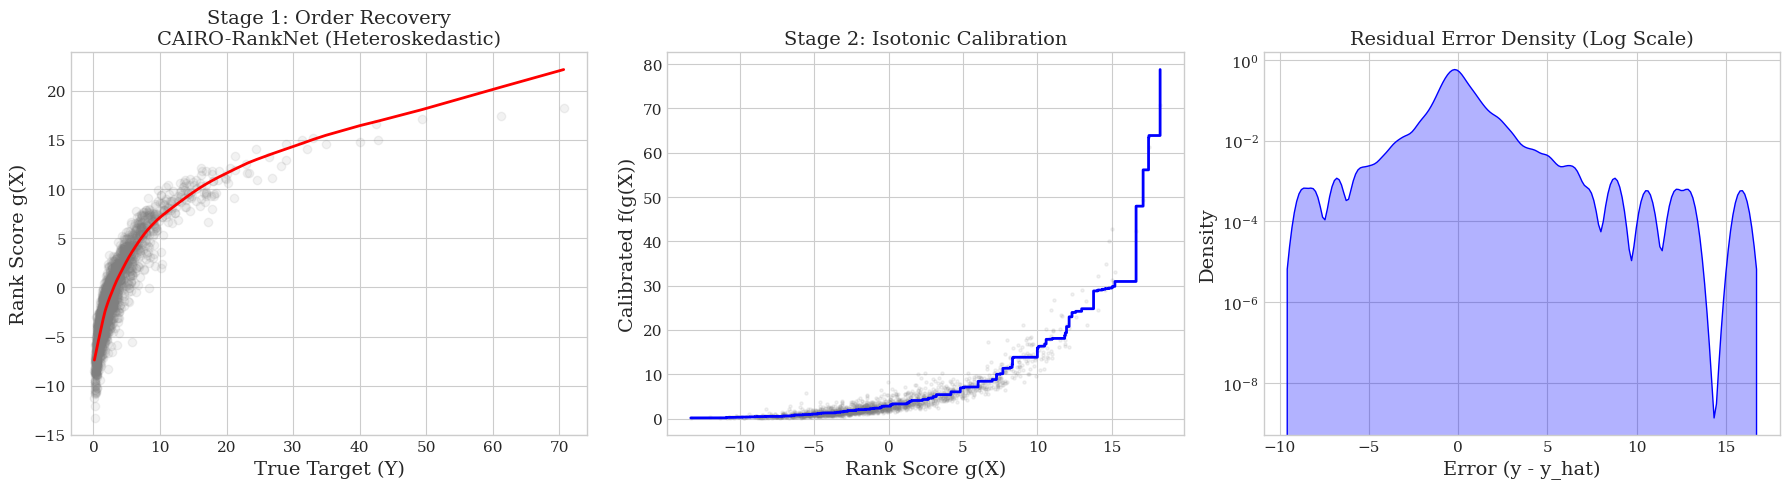


--- Repeat 2/10 ---

--- Repeat 3/10 ---

--- Repeat 4/10 ---

--- Repeat 5/10 ---

--- Repeat 6/10 ---

--- Repeat 7/10 ---

--- Repeat 8/10 ---

--- Repeat 9/10 ---

--- Repeat 10/10 ---


=== STUDY 1 (Variants vs Std Baselines) Results (Mean ± Std) ===
                                           MSE       Spearman
Regime          Model                                        
Heteroskedastic CAIRO-GiniW      2.100 ± 2.250  0.860 ± 0.117
                CAIRO-RankNet    2.147 ± 2.305  0.859 ± 0.118
                CAIRO-SoftRank   2.031 ± 2.242  0.878 ± 0.099
                NN-MSE           2.142 ± 2.571  0.870 ± 0.097
                RandForest      6.775 ± 10.491  0.840 ± 0.087
Normal          CAIRO-GiniW      1.176 ± 0.031  0.913 ± 0.092
                CAIRO-RankNet    1.230 ± 0.043  0.910 ± 0.093
                CAIRO-SoftRank   1.106 ± 0.035  0.921 ± 0.078
                NN-MSE           1.064 ± 0.027  0.921 ± 0.078
                RandForest       2.080 ± 0.595  0.882 ± 0.074

In [72]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from numpy.random import default_rng
from scipy.stats import spearmanr, kendalltau
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
# Check for LightGBM
try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.losses import Huber

# ==========================================
# 1. CONFIGURATION
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'

# Set DEBUG = False for the final high-quality paper run
DEBUG = False 

if DEBUG:
    N_REPEATS = 2
    N_SAMPLES = 2000
    EPOCHS = 10
    PAIRS = 5000
else:
    N_REPEATS = 10        # Number of runs for error bars
    N_SAMPLES = 8000      # Dataset size
    EPOCHS = 100          # Training duration
    PAIRS = 200_000       # Pairwise samples per epoch
    
D_IN = 10
SEED = 2026
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ==========================================
# 2. DATA GENERATION (The Regimes)
# ==========================================
def gen_data(regime, n, d=D_IN, seed=None):
    rr = default_rng(seed)
    X = rr.normal(size=(n, d)).astype('float32')
    w = rr.normal(size=d)
    eta = X @ w
    
    if regime == "Normal":
        # Standard Homoskedastic
        y = eta + rr.normal(size=n)
        
    elif regime == "Heteroskedastic":
        # Variance scales with signal (LogNormal style)
        mu = np.exp(eta / np.sqrt(d))
        epsilon = rr.lognormal(mean=0, sigma=0.6, size=n)
        y = mu + epsilon * np.sqrt(mu)
        
    elif regime == "Cauchy":
        # Extreme Heavy Tail (Undefined Mean/Variance)
        # We scale it down slightly so training doesn't instantly NaN, but tails are huge
        y = eta + rr.standard_cauchy(size=n) * 2.0
        # Clip strictly for numerical stability of baselines, 
        # but keep bounds massive so outliers remain outliers
        y = np.clip(y, -500, 500) 
        
    return X, y.astype('float32')

# ==========================================
# 3. MODEL ARCHITECTURES & LOSSES
# ==========================================
def quantile_loss(q, y, y_pred):
    e = y - y_pred
    return tf.reduce_mean(tf.maximum(q*e, (q-1)*e), axis=-1)

def soft_rank_loss(y_true, y_pred):
    """
    Differentiable Listwise Loss (SoftRank approximation).
    Maximizes correlation between y_true and soft ranks of y_pred.
    """
    # 1. Compute pairwise differences of scores
    y_pred = tf.cast(y_pred, tf.float32)
    y_true = tf.cast(y_true, tf.float32)
    diff = y_pred - tf.transpose(y_pred)
    
    # 2. Soft Rank via Sigmoid (Temperature=10 for sharpness)
    soft_ranks = tf.reduce_sum(tf.nn.sigmoid(10.0 * diff), axis=1, keepdims=True)
    
    # 3. Maximize covariance (minimize negative covariance)
    y_cent = y_true - tf.reduce_mean(y_true)
    r_cent = soft_ranks - tf.reduce_mean(soft_ranks)
    covariance = tf.reduce_mean(y_cent * r_cent)
    return -covariance

def build_net(d_in):
    """Standard shared backbone for all NN models"""
    return Sequential([
        layers.Input(shape=(d_in,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])

# ==========================================
# 4. PLOTTING FUNCTION (Mechanism)
# ==========================================
def plot_mechanism(y_true, s_uncal, s_cal, title_suffix=""):
    """Generates the 3-panel plot: Rank -> Calib -> Error"""
    fig = plt.figure(figsize=(18, 5))
    gs = GridSpec(1, 3, figure=fig)
    
    # Panel 1: Ranking (Stage 1)
    ax0 = fig.add_subplot(gs[0])
    # Subsample for plotting speed if needed
    idx = np.random.choice(len(y_true), min(len(y_true), 2000), replace=False)
    sns.regplot(x=y_true[idx], y=s_uncal[idx], lowess=True, 
                scatter_kws={'alpha':0.1, 'color':'gray'},
                line_kws={'color':'red', 'lw':2}, ax=ax0)
    ax0.set_title(f"Stage 1: Order Recovery\n{title_suffix}")
    ax0.set_xlabel("True Target (Y)")
    ax0.set_ylabel("Rank Score g(X)")
    
    # Panel 2: Calibration (Stage 2)
    ax1 = fig.add_subplot(gs[1])
    # Sort for step function
    sort_idx = np.argsort(s_uncal)
    ax1.step(s_uncal[sort_idx], s_cal[sort_idx], where='post', color='blue', lw=2)
    ax1.scatter(s_uncal[idx], y_true[idx], alpha=0.1, color='gray', s=5)
    ax1.set_title("Stage 2: Isotonic Calibration")
    ax1.set_xlabel("Rank Score g(X)")
    ax1.set_ylabel("Calibrated f(g(X))")
    
    # Panel 3: Error Density
    ax2 = fig.add_subplot(gs[2])
    res = y_true - s_cal
    sns.kdeplot(res, fill=True, color='blue', alpha=0.3, ax=ax2)
    ax2.set_yscale('log')
    ax2.set_title("Residual Error Density (Log Scale)")
    ax2.set_xlabel("Error (y - y_hat)")
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 5. EXPERIMENT LOOP
# ==========================================
results = []

# Define Studies
studies = {
    "Study 1 (Variants)": {
        "regimes": ["Normal", "Heteroskedastic"],
        "models": ["CAIRO-RankNet", "CAIRO-GiniW", "CAIRO-SoftRank", "NN-MSE", "RandForest"]
    },
    "Study 2 (Robustness)": {
        "regimes": ["Heteroskedastic", "Cauchy"],
        "models": ["CAIRO-RankNet", "NN-MSE", "NN-Huber", "NN-Quantile"]
    }
}

print(f"Starting Simulation Studies ({N_REPEATS} repeats)...")

for run in range(N_REPEATS):
    print(f"\n--- Repeat {run+1}/{N_REPEATS} ---")
    current_seed = SEED + run
    
    # Iterate over all unique regimes needed
    unique_regimes = set(studies["Study 1 (Variants)"]["regimes"] + studies["Study 2 (Robustness)"]["regimes"])
    
    for regime in unique_regimes:
        # Generate Data
        X, y = gen_data(regime, N_SAMPLES, seed=current_seed)
        
        # Standardize features (helps NNs)
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
        
        # Splits
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=current_seed)
        X_rn, X_cal, y_rn, y_cal = train_test_split(X_tr, y_tr, test_size=0.3, random_state=current_seed)
        
        # --- TRAIN MODELS ---
        
        # 1. CAIRO-RankNet
        # ----------------
        base_rn = build_net(D_IN)
        ii, ij = layers.Input((D_IN,)), layers.Input((D_IN,))
        out = layers.Activation('sigmoid')(layers.Subtract()([base_rn(ii), base_rn(ij)]))
        m_rn = Model([ii, ij], out)
        m_rn.compile(optimizer='adam', loss='binary_crossentropy')
        
        # Pair sampling
        rng = default_rng(current_seed)
        idx_i = rng.integers(0, len(y_rn), PAIRS)
        idx_j = rng.integers(0, len(y_rn), PAIRS)
        y_pairs = (y_rn[idx_i] > y_rn[idx_j]).astype('float32')
        
        m_rn.fit([X_rn[idx_i], X_rn[idx_j]], y_pairs, epochs=EPOCHS, batch_size=4096, verbose=0)
        
        # Calibration
        s_c = base_rn.predict(X_cal, verbose=0).flatten()
        s_t = base_rn.predict(X_te, verbose=0).flatten()
        iso = IsotonicRegression(out_of_bounds="clip").fit(s_c, y_cal)
        p_rn = iso.predict(s_t)
        
        # Store for plotting (only for one regime/run)
        if run == 0 and regime == "Heteroskedastic":
             plot_mechanism(y_te, s_t, p_rn, title_suffix="CAIRO-RankNet (Heteroskedastic)")

        # 2. CAIRO-GiniW (Weighted)
        # -------------------------
        base_gw = build_net(D_IN)
        m_gw = Model([ii, ij], layers.Activation('sigmoid')(layers.Subtract()([base_gw(ii), base_gw(ij)])))
        m_gw.compile(optimizer='adam', loss='binary_crossentropy')
        w_pairs = np.abs(y_rn[idx_i] - y_rn[idx_j])
        w_pairs = w_pairs / (w_pairs.mean() + 1e-6) # Normalize
        m_gw.fit([X_rn[idx_i], X_rn[idx_j]], y_pairs, sample_weight=w_pairs, epochs=EPOCHS, batch_size=4096, verbose=0)
        
        iso_gw = IsotonicRegression(out_of_bounds="clip").fit(base_gw.predict(X_cal, verbose=0).flatten(), y_cal)
        p_gw = iso_gw.predict(base_gw.predict(X_te, verbose=0).flatten())

        # 3. CAIRO-SoftRank (Listwise)
        # ----------------------------
        base_sr = build_net(D_IN)
        base_sr.compile(optimizer='adam', loss=soft_rank_loss)
        base_sr.fit(X_rn, y_rn.reshape(-1,1), epochs=EPOCHS, batch_size=256, verbose=0)
        
        iso_sr = IsotonicRegression(out_of_bounds="clip").fit(base_sr.predict(X_cal, verbose=0).flatten(), y_cal)
        p_sr = iso_sr.predict(base_sr.predict(X_te, verbose=0).flatten())

        # 4. NN-MSE (Baseline)
        # --------------------
        nn_mse = build_net(D_IN)
        nn_mse.compile(optimizer='adam', loss='mse')
        nn_mse.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=128, verbose=0)
        p_mse = nn_mse.predict(X_te, verbose=0).flatten()

        # 5. NN-Huber (Robust Baseline)
        # -----------------------------
        nn_huber = build_net(D_IN)
        nn_huber.compile(optimizer='adam', loss=Huber(delta=1.0))
        nn_huber.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=128, verbose=0)
        p_huber = nn_huber.predict(X_te, verbose=0).flatten()
        
        # 6. NN-Quantile (Robust Baseline)
        # --------------------------------
        nn_quant = build_net(D_IN)
        nn_quant.compile(optimizer='adam', loss=lambda y,f: quantile_loss(0.5, y, f))
        nn_quant.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=128, verbose=0)
        p_quant = nn_quant.predict(X_te, verbose=0).flatten()

        # 7. Random Forest
        # ----------------
        rf = RandomForestRegressor(n_estimators=100, min_samples_leaf=5, n_jobs=-1)
        rf.fit(X_tr, y_tr)
        p_rf = rf.predict(X_te)
        
        # 8. LightGBM (Optional)
        # ----------------------
        p_lgbm = np.zeros_like(y_te)
        if HAS_LGBM:
            lgbm = LGBMRegressor(n_jobs=1, verbose=-1)
            lgbm.fit(X_tr, y_tr)
            p_lgbm = lgbm.predict(X_te)

        # --- EVALUATION ---
        model_preds = {
            "CAIRO-RankNet": p_rn,
            "CAIRO-GiniW": p_gw,
            "CAIRO-SoftRank": p_sr,
            "NN-MSE": p_mse,
            "NN-Huber": p_huber,
            "NN-Quantile": p_quant,
            "RandForest": p_rf,
            "LightGBM": p_lgbm
        }
        
        for m_name, preds in model_preds.items():
            if m_name == "LightGBM" and not HAS_LGBM: continue
            
            rho, _ = spearmanr(y_te, preds)
            tau, _ = kendalltau(y_te, preds)
            mse_val = np.mean((y_te - preds)**2)
            
            results.append({
                "Run": run,
                "Regime": regime,
                "Model": m_name,
                "Spearman": rho,
                "Kendall": tau,
                "MSE": mse_val
            })

# ==========================================
# 6. RESULTS AGGREGATION & DISPLAY
# ==========================================
df = pd.DataFrame(results)

# Helper to filter and print tables
def print_study_table(study_name, df_full, config):
    print(f"\n\n=== {study_name} Results (Mean ± Std) ===")
    
    # Filter
    mask = (df_full["Regime"].isin(config["regimes"])) & \
           (df_full["Model"].isin(config["models"]))
    sub = df_full[mask].copy()
    
    # Aggregation
    agg = sub.groupby(["Regime", "Model"]).agg(
        MSE=("MSE", lambda x: f"{x.mean():.3f} ± {x.std():.3f}"),
        Spearman=("Spearman", lambda x: f"{x.mean():.3f} ± {x.std():.3f}")
    )
    print(agg)

# Print Tables
print_study_table("STUDY 1 (Variants vs Std Baselines)", df, studies["Study 1 (Variants)"])
print_study_table("STUDY 2 (Robustness vs Heavy Tails)", df, studies["Study 2 (Robustness)"])

print("\nSimulations Complete.")

Running simulations...
  > Simulating Normal Regime...
  > Simulating Heteroskedastic Regime...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saved to cairo_mechanism_both_regimes.pdf


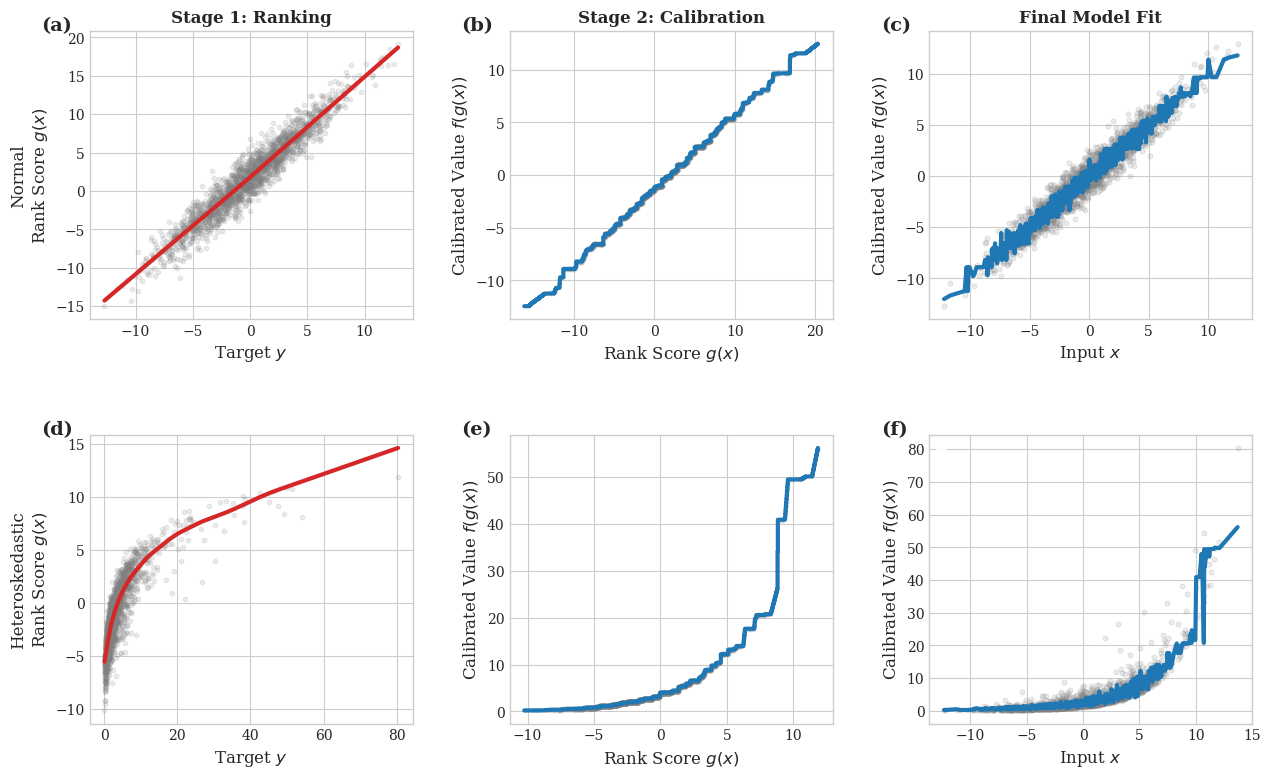

In [91]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from numpy.random import default_rng
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential

# ==========================================
# 1. Configuration & Style
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 2.5,
    'legend.fontsize': 9,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': 'white'
})

SEED = 2026
D_IN = 10
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
N_SAMPLES, EPOCHS, PAIRS = 12000, 100, 400_000

# ==========================================
# 2. Data & Models
# ==========================================
def gen_data(regime, n, d=D_IN, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n, d)).astype('float32')
    w = rr.normal(size=d)
    
    # True latent signal (x-axis for Panel C)
    eta = (X @ w).astype('float32') 
    
    if regime == "Normal":
        # Homoskedastic Gaussian
        y = eta + rr.normal(size=n)
    else: 
        # Heteroskedastic Lognormal
        mu = np.exp(eta / np.sqrt(d))
        epsilon = rr.lognormal(mean=0, sigma=0.8, size=n)
        y = mu + epsilon * np.sqrt(mu)
    
    return X, y.astype('float32'), eta

def build_net(d_in):
    return Sequential([
        layers.Input(shape=(d_in,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])

# ==========================================
# 3. Main Execution & Plotting
# ==========================================
print("Running simulations...")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

regimes = ["Normal", "Heteroskedastic"]
labels_grid = [['(a)', '(b)', '(c)'], ['(d)', '(e)', '(f)']]

for row_idx, regime in enumerate(regimes):
    print(f"  > Simulating {regime} Regime...")
    
    # 1. Generate & Split
    X, y, eta = gen_data(regime, N_SAMPLES, seed=SEED)
    X_tr, X_te, y_tr, y_te, eta_tr, eta_te = train_test_split(
        X, y, eta, test_size=0.3, random_state=SEED
    )
    X_rn, X_cal, y_rn, y_cal = train_test_split(X_tr, y_tr, test_size=0.3, random_state=SEED)

    # 2. Train CAIRO
    base = build_net(D_IN)
    ii, ij = layers.Input((D_IN,)), layers.Input((D_IN,))
    out = layers.Activation('sigmoid')(layers.Subtract()([base(ii), base(ij)]))
    ranker = Model([ii, ij], out)
    ranker.compile(optimizer='adam', loss='binary_crossentropy')
    
    rr = default_rng(SEED)
    idx_i = rr.integers(0, len(y_rn), PAIRS)
    idx_j = rr.integers(0, len(y_rn), PAIRS)
    y_pairs = (y_rn[idx_i] > y_rn[idx_j]).astype('float32')
    ranker.fit([X_rn[idx_i], X_rn[idx_j]], y_pairs, epochs=EPOCHS, batch_size=4096, verbose=0)
    
    s_cal = base.predict(X_cal, verbose=0).flatten()
    s_te = base.predict(X_te, verbose=0).flatten()
    iso = IsotonicRegression(out_of_bounds="clip").fit(s_cal, y_cal)
    yhat_cairo = iso.predict(s_te)

    # 3. Plotting
    idx = np.random.choice(len(y_te), min(2000, len(y_te)), replace=False)
    
    # --- Column 1: Rank Recovery ---
    ax1 = axes[row_idx, 0]
    sns.regplot(x=y_te[idx], y=s_te[idx], lowess=True, 
                scatter_kws={'alpha':0.15, 's':10, 'color':'gray', 'rasterized':True},
                line_kws={'color':'#d62728', 'lw':3, 'label': 'Rank Score $g(x)$'}, ax=ax1)
    
    ax1.set_xlabel("Target $y$")
    ax1.set_ylabel(f"{regime}\nRank Score $g(x)$")
    ax1.text(-0.15, 1.05, labels_grid[row_idx][0], transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top')
    if row_idx == 0: ax1.set_title("Stage 1: Ranking", fontsize=12, fontweight='bold')

    # --- Column 2: Calibration Map ---
    ax2 = axes[row_idx, 1]
    x_grid = np.linspace(s_te.min(), s_te.max(), 1000)
    y_grid = iso.predict(x_grid)
    
    ax2.step(x_grid, y_grid, color='#1f77b4', lw=3, where='post', label='Isotonic Map')
    ax2.scatter(s_te[idx], yhat_cairo[idx], alpha=0.1, s=10, color='gray', rasterized=True)
    
    ax2.set_xlabel("Rank Score $g(x)$")
    ax2.set_ylabel("Calibrated Value $f(g(x))$")
    ax2.text(-0.15, 1.05, labels_grid[row_idx][1], transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top')
    if row_idx == 0: ax2.set_title("Stage 2: Calibration", fontsize=12, fontweight='bold')

    # --- Column 3: Final Fit (Input Space) ---
    ax3 = axes[row_idx, 2]
    sort_idx = np.argsort(eta_te[idx])
    
    ax3.scatter(eta_te[idx], y_te[idx], alpha=0.15, s=12, color='gray', rasterized=True)
    ax3.plot(eta_te[idx][sort_idx], yhat_cairo[idx][sort_idx], color='#1f77b4', lw=3)
    
    ax3.set_xlabel("Input $x$")
    ax3.set_ylabel("Calibrated Value $f(g(x))$")
    ax3.text(-0.15, 1.05, labels_grid[row_idx][2], transform=ax3.transAxes, fontsize=14, fontweight='bold', va='top')
    if row_idx == 0: ax3.set_title("Final Model Fit", fontsize=12, fontweight='bold')
    if row_idx == 1: ax3.legend(loc='upper left')

# Save
plt.savefig("cairo_mechanism_both_regimes.pdf", dpi=300, bbox_inches='tight')
print("Saved to cairo_mechanism_both_regimes.pdf")
plt.show()

Starting combined figure generation...
Processing Regime: Normal...
Processing Regime: Heteroskedastic Tail...
Generating mechanism plots...
Saving figure...
Done. Saved to neurips_combined_figure.png


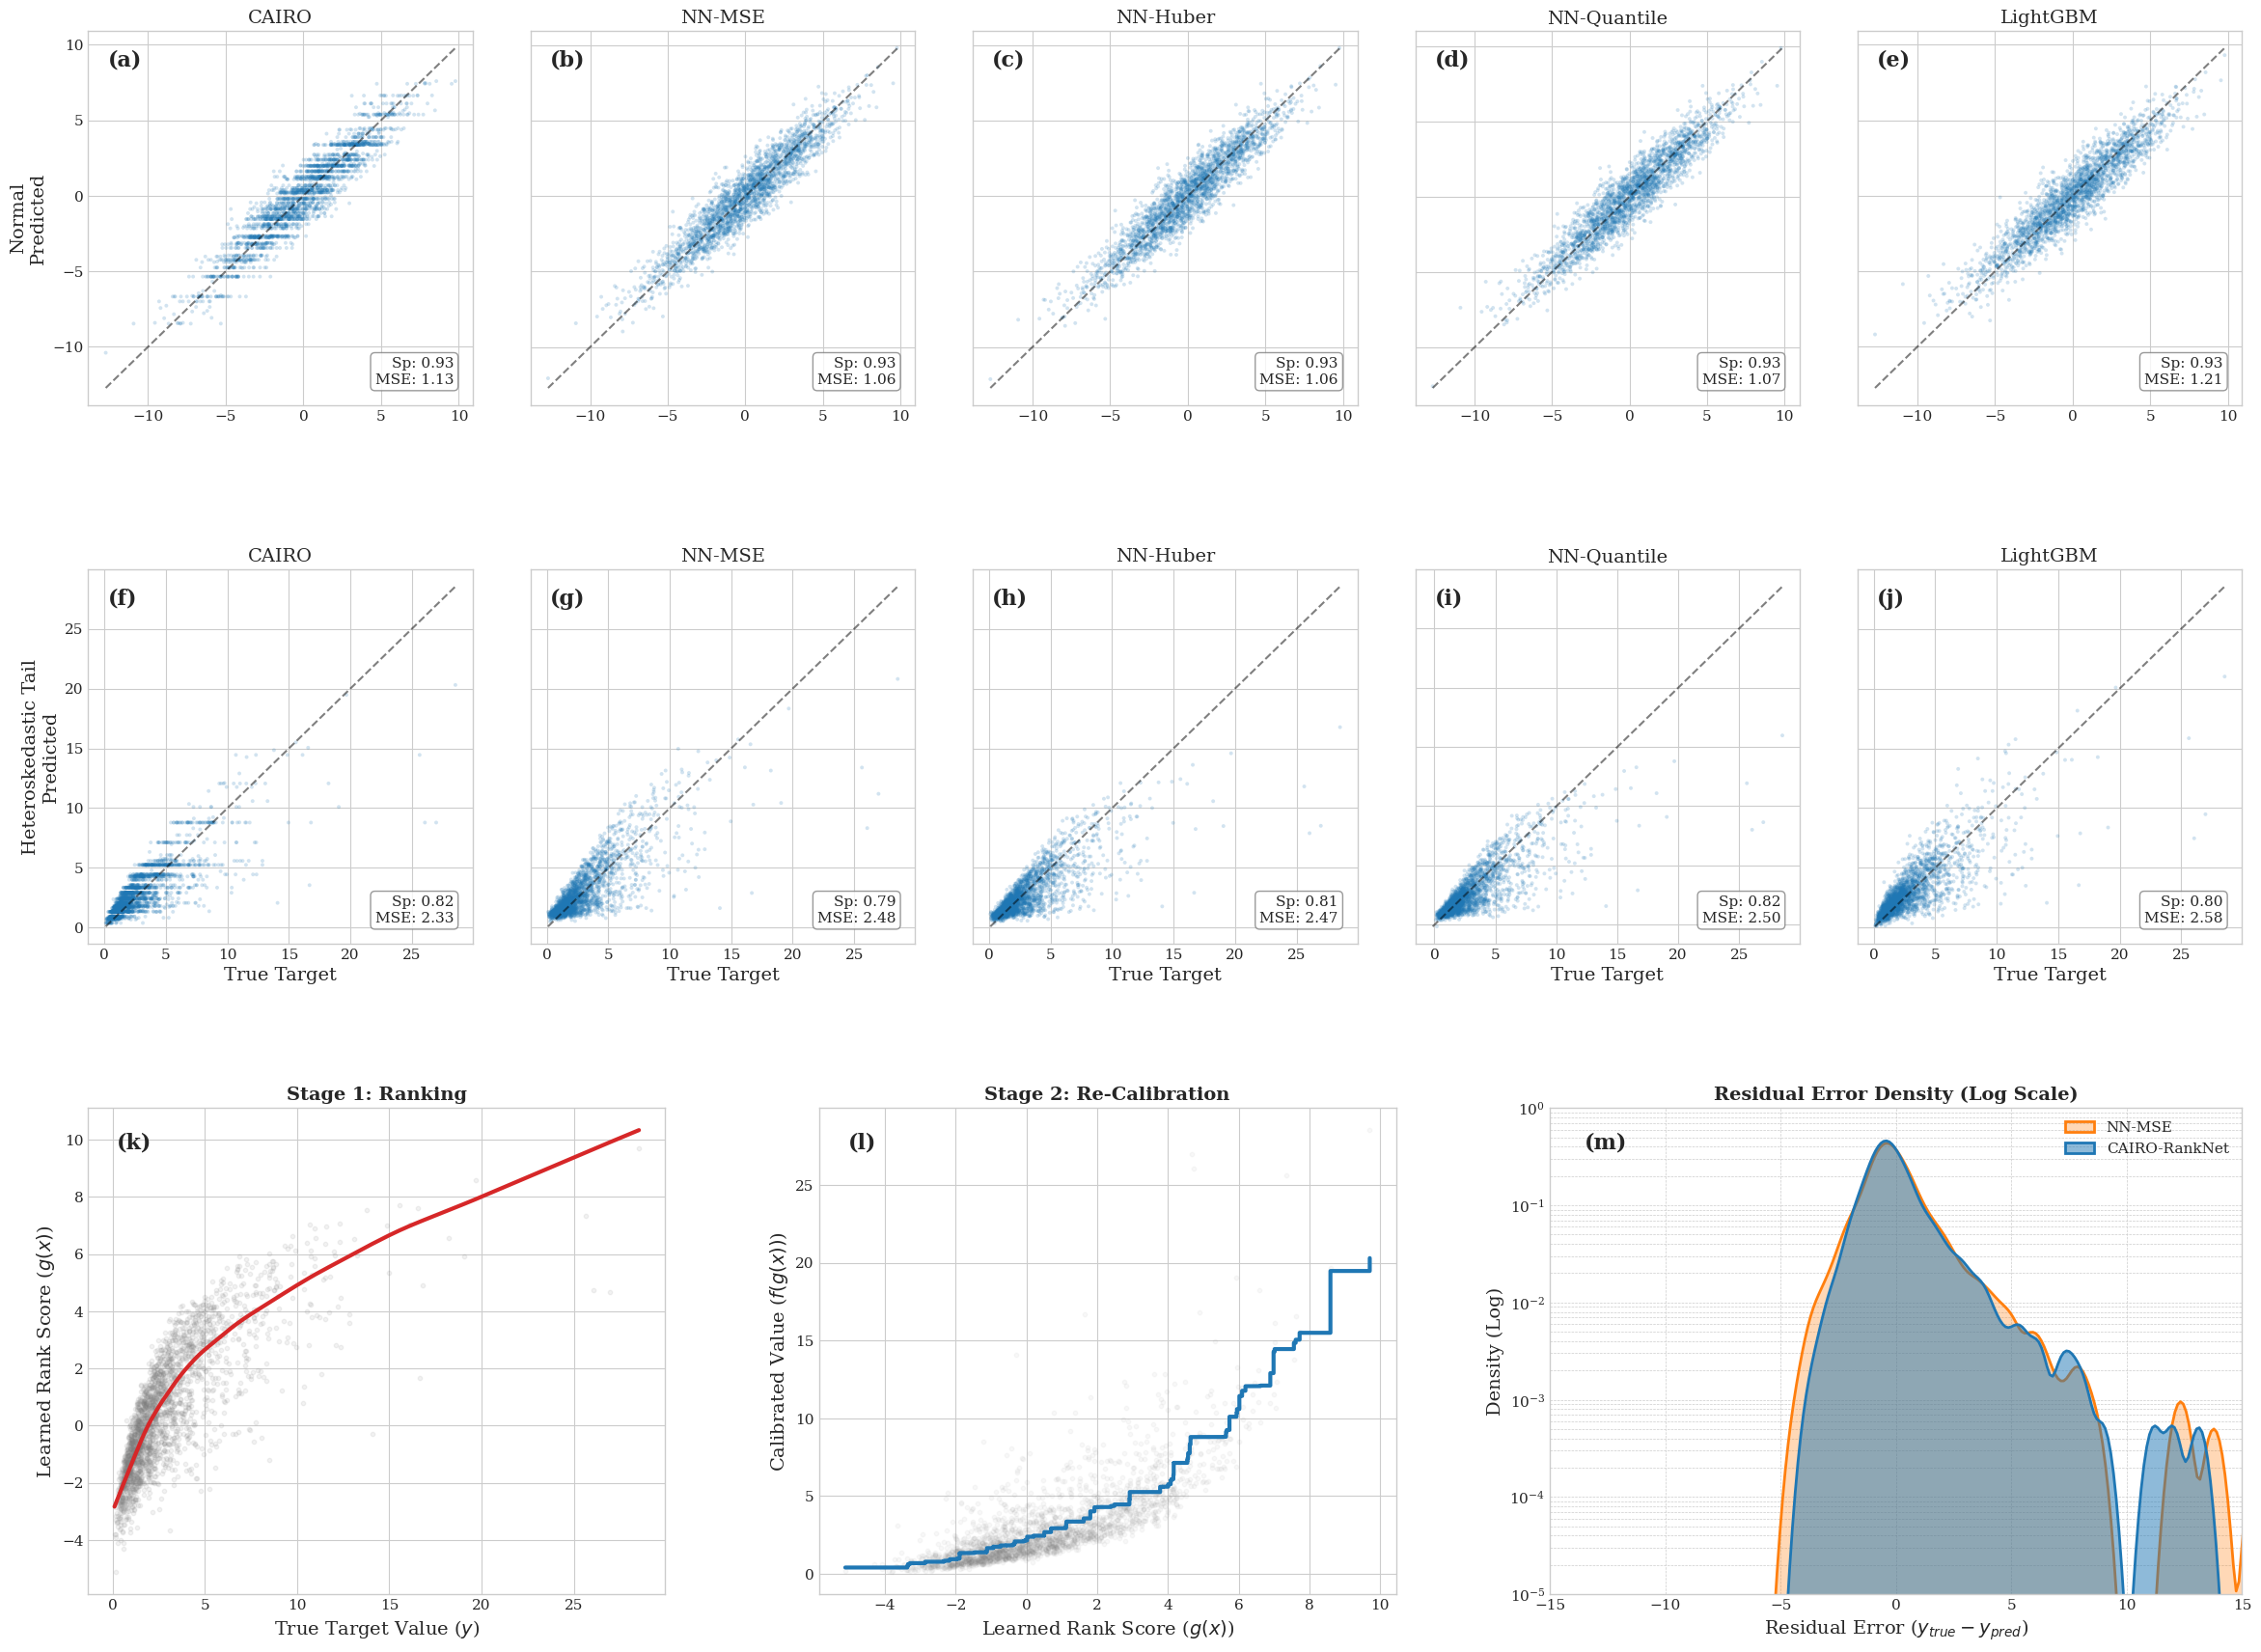

In [66]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from numpy.random import default_rng
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
from lightgbm import LGBMRegressor
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.losses import Huber

# ==========================================
# Configuration & Setup
# ==========================================
# Set style for professional publication plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

# DEBUG = True
DEBUG = True # Set to False for higher quality run
SEED = 20260209 
D_IN = 10
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

if DEBUG:
    N_SAMPLES, EPOCHS, PAIRS = 8000, 60, 70_000
else:
    # Higher samples for cleaner density plots at the end
    N_SAMPLES, EPOCHS, PAIRS = 12000, 150, 500_000 

# ==========================================
# Helper Functions (Data & Models)
# ==========================================
def quantile_loss(q, y, y_pred):
    e = y - y_pred
    return tf.reduce_mean(tf.maximum(q*e, (q-1)*e), axis=-1)

def gen_data(regime, n, d=D_IN, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n, d)).astype('float32')
    w = rr.normal(size=d)
    eta = X @ w
    if regime == "Normal":
        y = eta + rr.normal(size=n)
    else: 
        # Heteroskedastic + Heavy Tail
        mu = np.exp(eta / np.sqrt(d))
        epsilon = rr.lognormal(mean=0, sigma=0.8, size=n)
        y = mu + epsilon * np.sqrt(mu)
    return X, y.astype('float32')

def build_deep_net(d_in):
    return Sequential([
        layers.Input(shape=(d_in,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])

# placeholders to save data for the bottom row plots
saved_data = {} 

# ==========================================
# Main Execution Loop
# ==========================================
print("Starting combined figure generation...")

# Initialize Figure and Outer GridSpec (3 Rows)
fig = plt.figure(figsize=(24, 18))
outer_grid = GridSpec(3, 1, figure=fig, height_ratios=[1, 1, 1.3], hspace=0.4)

# Labels for the 2x5 benchmark grid
bench_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)']
model_names = ["CAIRO", "NN-MSE", "NN-Huber", "NN-Quantile", "LightGBM"]
regimes = ["Normal", "Heteroskedastic Tail"]

# --- TOP TWO ROWS: BENCHMARK GRID ---
for row_idx, regime in enumerate(regimes):
    print(f"Processing Regime: {regime}...")
    
    # --- FIX IS HERE: Use subgridspec instead of getFromSubplotSpec ---
    inner_grid = outer_grid[row_idx].subgridspec(1, 5, wspace=0.15)
    
    X, y = gen_data(regime, N_SAMPLES, seed=SEED)
    X_tr_full, X_te, y_tr_full, y_te = train_test_split(X, y, test_size=0.3, random_state=SEED)
    X_rn, X_cal, y_rn, y_cal = train_test_split(X_tr_full, y_tr_full, test_size=0.3, random_state=SEED)

    # 1. CAIRO
    branch = build_deep_net(D_IN)
    input_i, input_j = layers.Input(shape=(D_IN,)), layers.Input(shape=(D_IN,))
    diff = layers.Subtract()([branch(input_i), branch(input_j)])
    prob = layers.Activation('sigmoid')(diff)
    ranknet = Model(inputs=[input_i, input_j], outputs=prob)
    ranknet.compile(optimizer='adam', loss='binary_crossentropy')
    
    rr = default_rng(SEED)
    idx_i, idx_j = rr.integers(0, len(y_rn), PAIRS), rr.integers(0, len(y_rn), PAIRS)
    y_pairs = (y_rn[idx_i] > y_rn[idx_j]).astype('float32')
    ranknet.fit([X_rn[idx_i], X_rn[idx_j]], y_pairs, epochs=EPOCHS, batch_size=4096, verbose=0)
    
    # Get scores and calibrate
    s_te_uncal = branch.predict(X_te, verbose=0).flatten()
    s_cal_uncal = branch.predict(X_cal, verbose=0).flatten()
    iso = IsotonicRegression(out_of_bounds="clip").fit(s_cal_uncal, y_cal)
    yhat_cairo = iso.predict(s_te_uncal)

    # 2. Baselines
    nn_mse = build_deep_net(D_IN)
    nn_mse.compile(optimizer='adam', loss='mse')
    nn_mse.fit(X_tr_full, y_tr_full, epochs=EPOCHS, batch_size=256, verbose=0)
    yhat_mse = nn_mse.predict(X_te, verbose=0).flatten()

    nn_huber = build_deep_net(D_IN)
    nn_huber.compile(optimizer='adam', loss=Huber(delta=1.0))
    nn_huber.fit(X_tr_full, y_tr_full, epochs=EPOCHS, batch_size=256, verbose=0)
    yhat_huber = nn_huber.predict(X_te, verbose=0).flatten()

    nn_quant = build_deep_net(D_IN)
    nn_quant.compile(optimizer='adam', loss=lambda y, f: quantile_loss(0.5, y, f))
    nn_quant.fit(X_tr_full, y_tr_full, epochs=EPOCHS, batch_size=256, verbose=0)
    yhat_quant = nn_quant.predict(X_te, verbose=0).flatten()

    lgbm = LGBMRegressor(random_state=SEED, n_jobs=1, verbose=-1)
    lgbm.fit(X_tr_full, y_tr_full)
    yhat_lgbm = lgbm.predict(X_te)

    preds_list = [yhat_cairo, yhat_mse, yhat_huber, yhat_quant, yhat_lgbm]

    # Save data for bottom row if this is the difficult regime
    if regime == "Heteroskedastic Tail":
        saved_data['y_te'] = y_te
        saved_data['s_te_uncal'] = s_te_uncal # Stage 1 scores
        saved_data['yhat_cairo'] = yhat_cairo # Stage 2 predictions
        saved_data['yhat_mse'] = yhat_mse # Baseline comparisons
        saved_data['iso_model'] = iso

    # Plotting Loop for Top 2 Rows
    for col_idx, yhat in enumerate(preds_list):
        ax = fig.add_subplot(inner_grid[col_idx])
        
        # Shared Y-axis for sanity
        if col_idx > 0: plt.setp(ax.get_yticklabels(), visible=False)
        
        ax.scatter(y_te, yhat, alpha=0.2, s=8, color='#1f77b4', edgecolors='none')
        lims = [np.min([y_te.min(), yhat.min()]), np.max([y_te.max(), yhat.max()])]
        ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.5)
        
        ax.set_title(f"{model_names[col_idx]}", fontsize=14)
        if row_idx == 1: ax.set_xlabel("True Target", fontsize=14)
        if col_idx == 0: ax.set_ylabel(f"{regime}\nPredicted", fontsize=14)
        
        # Label and Metrics
        label_txt = bench_labels[row_idx*5 + col_idx]
        rho, _ = spearmanr(y_te, yhat)
        mse = np.mean((y_te - yhat)**2)
        stats_txt = f"Sp: {rho:.2f}\nMSE: {mse:.2f}"
        
        ax.text(0.05, 0.95, label_txt, transform=ax.transAxes, 
                fontsize=16, fontweight='bold', va='top')
        ax.text(0.95, 0.05, stats_txt, transform=ax.transAxes, 
                fontsize=11, va='bottom', ha='right', 
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='grey', boxstyle='round'))


# --- BOTTOM ROW: MECHANISM PLOTS (Derived from Heteroskedastic data) ---
print("Generating mechanism plots...")
# --- FIX IS HERE: Use subgridspec ---
mech_grid = outer_grid[2].subgridspec(1, 3, wspace=0.25, width_ratios=[1,1,1.2])
mech_labels = ['(k)', '(l)', '(m)']

# Retrieve saved data
y_te_m = saved_data['y_te']
s_uncal_m = saved_data['s_te_uncal']
y_cal_m = saved_data['yhat_cairo']
y_mse_m = saved_data['yhat_mse']
iso_model = saved_data['iso_model']

# --- Panel (k): Stage 1 Order Recovery ---
ax_k = fig.add_subplot(mech_grid[0])
sns.regplot(x=y_te_m, y=s_uncal_m, lowess=True, scatter_kws={'alpha':0.1, 's':10, 'color':'gray'}, 
            line_kws={'color':'#d62728', 'lw':3}, ax=ax_k)
ax_k.set_title("Stage 1: Ranking", fontsize=14, fontweight='bold')
ax_k.set_xlabel("True Target Value ($y$)", fontsize=14)
ax_k.set_ylabel("Learned Rank Score ($g(x)$)", fontsize=14)
ax_k.text(0.05, 0.95, mech_labels[0], transform=ax_k.transAxes, fontsize=16, fontweight='bold', va='top')

# --- Panel (l): Stage 2 Scale Recovery ---
ax_l = fig.add_subplot(mech_grid[1])
sort_idx = np.argsort(s_uncal_m)
# Plot mapping function (step)
ax_l.step(s_uncal_m[sort_idx], y_cal_m[sort_idx], color='#1f77b4', lw=3, where='post', label='Isotonic Map')
# Plot scatter points to show distribution
ax_l.scatter(s_uncal_m, y_te_m, alpha=0.05, s=10, color='gray')
ax_l.set_title("Stage 2: Re-Calibration", fontsize=14, fontweight='bold')
ax_l.set_xlabel("Learned Rank Score ($g(x)$)", fontsize=14)
ax_l.set_ylabel("Calibrated Value ($f(g(x))$)", fontsize=14)
ax_l.text(0.05, 0.95, mech_labels[1], transform=ax_l.transAxes, fontsize=16, fontweight='bold', va='top')

# --- Panel (m): Error Density (Log Scale) ---
ax_m = fig.add_subplot(mech_grid[2])
residuals_cairo = y_te_m - y_cal_m
residuals_mse = y_te_m - y_mse_m

sns.kdeplot(residuals_mse, fill=True, color='#ff7f0e', label='NN-MSE', alpha=0.3, linewidth=2, ax=ax_m, clip=(-20, 20))
sns.kdeplot(residuals_cairo, fill=True, color='#1f77b4', label='CAIRO-RankNet', alpha=0.5, linewidth=2, ax=ax_m, clip=(-20, 20))

ax_m.set_yscale('log')
# Zoom in on relevant area depending on random seed, but keep it roughly symmetric around 0
ax_m.set_xlim(-15, 15) 
# Ensure log scale ticks are readable
ax_m.set_ylim(bottom=1e-5, top=1.0)

ax_m.set_title("Residual Error Density (Log Scale)", fontsize=14, fontweight='bold')
ax_m.set_xlabel("Residual Error ($y_{true} - y_{pred}$)", fontsize=14)
ax_m.set_ylabel("Density (Log)", fontsize=14)
ax_m.legend(fontsize=11, loc='upper right')
ax_m.text(0.05, 0.95, mech_labels[2], transform=ax_m.transAxes, fontsize=16, fontweight='bold', va='top')
ax_m.grid(True, which="both", ls="--", linewidth=0.5)

print("Saving figure...")
# Adjust layout to prevent overlaps
plt.subplots_adjust(left=0.05, right=0.98, top=0.95, bottom=0.05)
plt.savefig("neurips_combined_figure.png", dpi=300, bbox_inches='tight')
print("Done. Saved to neurips_combined_figure.png")

Starting benchmark (10 runs)...
--- Run 1/10 ---
--- Run 2/10 ---
--- Run 3/10 ---
--- Run 4/10 ---
--- Run 5/10 ---
--- Run 6/10 ---
--- Run 7/10 ---
--- Run 8/10 ---
--- Run 9/10 ---
--- Run 10/10 ---
Generating mechanism plots (for final run)...
Saving figure...
Done. Saved to neurips_combined_figure_repeated.png

=== Final Aggregated Metrics (Mean ± Std Dev) ===
                                  Spearman_Mean  Spearman_Std  Kendall_Mean  Kendall_Std  MSE_Mean   MSE_Std
Regime               Model                                                                                  
Heteroskedastic Tail CAIRO             0.826728      0.053785      0.659185     0.058851  3.242210  0.594454
                     LightGBM          0.815843      0.046699      0.631554     0.049705  4.101471  1.475014
                     NN-Huber          0.836541      0.046905      0.657868     0.053347  3.625045  1.133161
                     NN-MSE            0.812951      0.039933      0.629097     0.0439

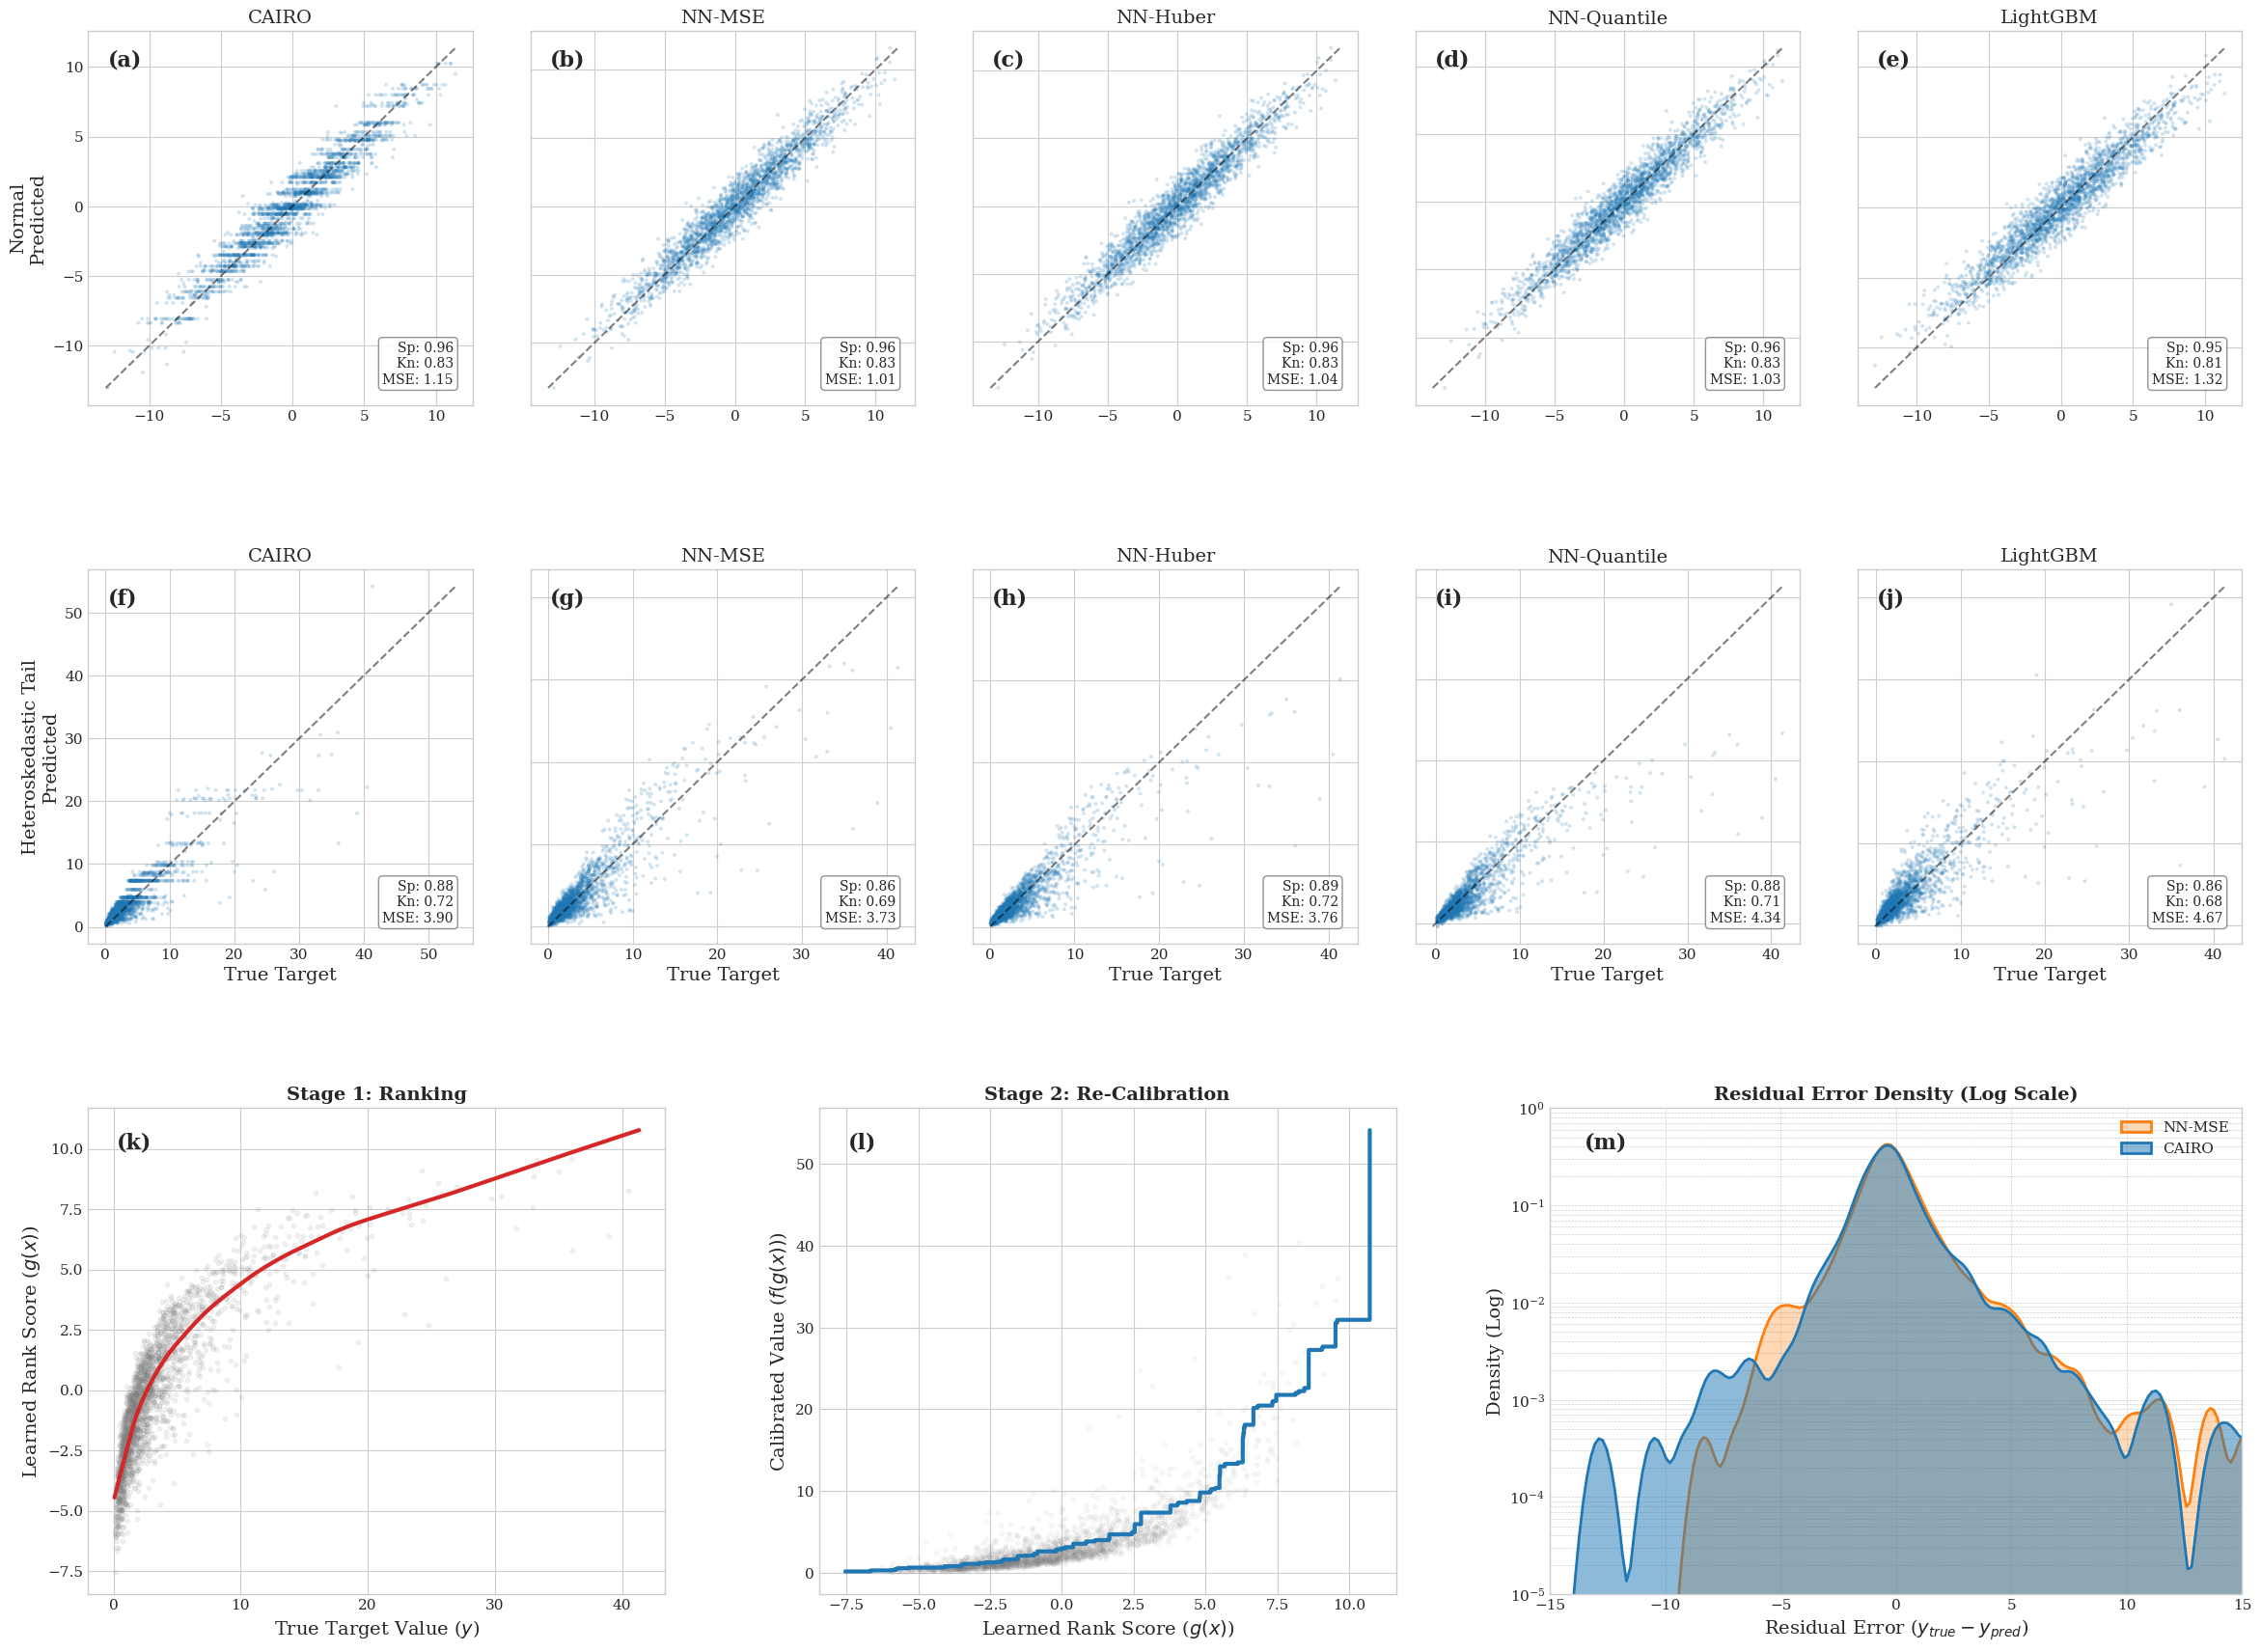

In [71]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from numpy.random import default_rng
from scipy.stats import spearmanr, kendalltau
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
from lightgbm import LGBMRegressor
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.losses import Huber

# ==========================================
# Configuration & Setup
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

DEBUG = False # Set to False for higher quality run
SEED = 20260209 
D_IN = 10
N_REPEATS = 10 # Requested: Run 10 times
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

if DEBUG:
    N_SAMPLES, EPOCHS, PAIRS = 2000, 10, 5000
else:
    # Requested: 8000 samples
    N_SAMPLES, EPOCHS, PAIRS = 8000, 100, 200_000 

# ==========================================
# Helper Functions (Data & Models)
# ==========================================
def quantile_loss(q, y, y_pred):
    e = y - y_pred
    return tf.reduce_mean(tf.maximum(q*e, (q-1)*e), axis=-1)

def gen_data(regime, n, d=D_IN, seed=None):
    # Use specific seed if provided, else random
    rr = default_rng(seed) if seed is not None else default_rng()
    X = rr.normal(size=(n, d)).astype('float32')
    w = rr.normal(size=d)
    eta = X @ w
    if regime == "Normal":
        y = eta + rr.normal(size=n)
    else: 
        # Heteroskedastic + Heavy Tail
        mu = np.exp(eta / np.sqrt(d))
        epsilon = rr.lognormal(mean=0, sigma=0.8, size=n)
        y = mu + epsilon * np.sqrt(mu)
    return X, y.astype('float32')

def build_deep_net(d_in):
    # Requested: Revert width to 16 (do not use 32)
    return Sequential([
        layers.Input(shape=(d_in,)),
        layers.Dense(16, activation='relu'), 
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])

# ==========================================
# Main Execution Loop
# ==========================================
print(f"Starting benchmark ({N_REPEATS} runs)...")

model_names = ["CAIRO", "NN-MSE", "NN-Huber", "NN-Quantile", "LightGBM"]
regimes = ["Normal", "Heteroskedastic Tail"]
bench_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)']

all_metrics_list = []

# Loop for Repeats
for run_idx in range(N_REPEATS):
    print(f"--- Run {run_idx + 1}/{N_REPEATS} ---")
    
    # We re-initialize the figure ONLY on the last run to save the plot
    if run_idx == N_REPEATS - 1:
        fig = plt.figure(figsize=(24, 18))
        outer_grid = GridSpec(3, 1, figure=fig, height_ratios=[1, 1, 1.3], hspace=0.4)
    
    # Placeholders for mechanism plot data (saved from the last run)
    saved_data = {} 

    for row_idx, regime in enumerate(regimes):
        # Generate fresh data for each run (random seed varies per run)
        current_seed = SEED + run_idx 
        X, y = gen_data(regime, N_SAMPLES, seed=current_seed)
        
        X_tr_full, X_te, y_tr_full, y_te = train_test_split(X, y, test_size=0.3, random_state=current_seed)
        X_rn, X_cal, y_rn, y_cal = train_test_split(X_tr_full, y_tr_full, test_size=0.3, random_state=current_seed)

        # 1. CAIRO
        branch = build_deep_net(D_IN)
        input_i, input_j = layers.Input(shape=(D_IN,)), layers.Input(shape=(D_IN,))
        diff = layers.Subtract()([branch(input_i), branch(input_j)])
        prob = layers.Activation('sigmoid')(diff)
        ranknet = Model(inputs=[input_i, input_j], outputs=prob)
        ranknet.compile(optimizer='adam', loss='binary_crossentropy')
        
        rr = default_rng(current_seed)
        idx_i, idx_j = rr.integers(0, len(y_rn), PAIRS), rr.integers(0, len(y_rn), PAIRS)
        y_pairs = (y_rn[idx_i] > y_rn[idx_j]).astype('float32')
        ranknet.fit([X_rn[idx_i], X_rn[idx_j]], y_pairs, epochs=EPOCHS, batch_size=4096, verbose=0)
        
        s_te_uncal = branch.predict(X_te, verbose=0).flatten()
        s_cal_uncal = branch.predict(X_cal, verbose=0).flatten()
        iso = IsotonicRegression(out_of_bounds="clip").fit(s_cal_uncal, y_cal)
        yhat_cairo = iso.predict(s_te_uncal)

        # 2. Baselines
        nn_mse = build_deep_net(D_IN)
        nn_mse.compile(optimizer='adam', loss='mse')
        nn_mse.fit(X_tr_full, y_tr_full, epochs=EPOCHS, batch_size=256, verbose=0)
        yhat_mse = nn_mse.predict(X_te, verbose=0).flatten()

        nn_huber = build_deep_net(D_IN)
        nn_huber.compile(optimizer='adam', loss=Huber(delta=1.0))
        nn_huber.fit(X_tr_full, y_tr_full, epochs=EPOCHS, batch_size=256, verbose=0)
        yhat_huber = nn_huber.predict(X_te, verbose=0).flatten()

        nn_quant = build_deep_net(D_IN)
        nn_quant.compile(optimizer='adam', loss=lambda y, f: quantile_loss(0.5, y, f))
        nn_quant.fit(X_tr_full, y_tr_full, epochs=EPOCHS, batch_size=256, verbose=0)
        yhat_quant = nn_quant.predict(X_te, verbose=0).flatten()

        lgbm = LGBMRegressor(random_state=current_seed, n_jobs=1, verbose=-1)
        lgbm.fit(X_tr_full, y_tr_full)
        yhat_lgbm = lgbm.predict(X_te)

        preds_list = [yhat_cairo, yhat_mse, yhat_huber, yhat_quant, yhat_lgbm]

        # Save data for mechanism plots (only needed for the last run)
        if run_idx == N_REPEATS - 1:
            if regime == "Heteroskedastic Tail":
                saved_data['y_te'] = y_te
                saved_data['s_te_uncal'] = s_te_uncal
                saved_data['yhat_cairo'] = yhat_cairo
                saved_data['yhat_mse'] = yhat_mse

            # Plotting (Only on last run)
            inner_grid = outer_grid[row_idx].subgridspec(1, 5, wspace=0.15)
            for col_idx, yhat in enumerate(preds_list):
                ax = fig.add_subplot(inner_grid[col_idx])
                
                if col_idx > 0: plt.setp(ax.get_yticklabels(), visible=False)
                
                ax.scatter(y_te, yhat, alpha=0.2, s=8, color='#1f77b4', edgecolors='none')
                lims = [np.min([y_te.min(), yhat.min()]), np.max([y_te.max(), yhat.max()])]
                ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.5)
                
                ax.set_title(f"{model_names[col_idx]}", fontsize=14)
                if row_idx == 1: ax.set_xlabel("True Target", fontsize=14)
                if col_idx == 0: ax.set_ylabel(f"{regime}\nPredicted", fontsize=14)
                
                # Calculate metrics for annotation
                rho, _ = spearmanr(y_te, yhat)
                tau, _ = kendalltau(y_te, yhat)
                mse = np.mean((y_te - yhat)**2)
                
                stats_txt = f"Sp: {rho:.2f}\nKn: {tau:.2f}\nMSE: {mse:.2f}"
                label_txt = bench_labels[row_idx*5 + col_idx]
                
                ax.text(0.05, 0.95, label_txt, transform=ax.transAxes, 
                        fontsize=16, fontweight='bold', va='top')
                ax.text(0.95, 0.05, stats_txt, transform=ax.transAxes, 
                        fontsize=10, va='bottom', ha='right', 
                        bbox=dict(facecolor='white', alpha=0.85, edgecolor='grey', boxstyle='round'))

        # Collect Metrics (For ALL runs)
        for col_idx, yhat in enumerate(preds_list):
            rho, _ = spearmanr(y_te, yhat)
            tau, _ = kendalltau(y_te, yhat)
            mse = np.mean((y_te - yhat)**2)
            
            all_metrics_list.append({
                "Run": run_idx,
                "Regime": regime,
                "Model": model_names[col_idx],
                "Spearman": rho,
                "Kendall": tau,
                "MSE": mse
            })

# --- BOTTOM ROW: MECHANISM PLOTS (Last Run Only) ---
if N_REPEATS > 0:
    print("Generating mechanism plots (for final run)...")
    mech_grid = outer_grid[2].subgridspec(1, 3, wspace=0.25, width_ratios=[1,1,1.2])
    mech_labels = ['(k)', '(l)', '(m)']

    y_te_m = saved_data['y_te']
    s_uncal_m = saved_data['s_te_uncal']
    y_cal_m = saved_data['yhat_cairo']
    y_mse_m = saved_data['yhat_mse']

    # (k) Stage 1
    ax_k = fig.add_subplot(mech_grid[0])
    sns.regplot(x=y_te_m, y=s_uncal_m, lowess=True, scatter_kws={'alpha':0.1, 's':10, 'color':'gray'}, 
                line_kws={'color':'#d62728', 'lw':3}, ax=ax_k)
    ax_k.set_title("Stage 1: Ranking", fontsize=14, fontweight='bold')
    ax_k.set_xlabel("True Target Value ($y$)", fontsize=14)
    ax_k.set_ylabel("Learned Rank Score ($g(x)$)", fontsize=14)
    ax_k.text(0.05, 0.95, mech_labels[0], transform=ax_k.transAxes, fontsize=16, fontweight='bold', va='top')

    # (l) Stage 2
    ax_l = fig.add_subplot(mech_grid[1])
    sort_idx = np.argsort(s_uncal_m)
    ax_l.step(s_uncal_m[sort_idx], y_cal_m[sort_idx], color='#1f77b4', lw=3, where='post', label='Isotonic Map')
    ax_l.scatter(s_uncal_m, y_te_m, alpha=0.05, s=10, color='gray')
    ax_l.set_title("Stage 2: Re-Calibration", fontsize=14, fontweight='bold')
    ax_l.set_xlabel("Learned Rank Score ($g(x)$)", fontsize=14)
    ax_l.set_ylabel("Calibrated Value ($f(g(x))$)", fontsize=14)
    ax_l.text(0.05, 0.95, mech_labels[1], transform=ax_l.transAxes, fontsize=16, fontweight='bold', va='top')

    # (m) Error Density
    ax_m = fig.add_subplot(mech_grid[2])
    residuals_cairo = y_te_m - y_cal_m
    residuals_mse = y_te_m - y_mse_m

    sns.kdeplot(residuals_mse, fill=True, color='#ff7f0e', label='NN-MSE', alpha=0.3, linewidth=2, ax=ax_m, clip=(-20, 20))
    sns.kdeplot(residuals_cairo, fill=True, color='#1f77b4', label='CAIRO', alpha=0.5, linewidth=2, ax=ax_m, clip=(-20, 20))

    ax_m.set_yscale('log')
    ax_m.set_xlim(-15, 15) 
    ax_m.set_ylim(bottom=1e-5, top=1.0)
    ax_m.set_title("Residual Error Density (Log Scale)", fontsize=14, fontweight='bold')
    ax_m.set_xlabel("Residual Error ($y_{true} - y_{pred}$)", fontsize=14)
    ax_m.set_ylabel("Density (Log)", fontsize=14)
    ax_m.legend(fontsize=11, loc='upper right')
    ax_m.text(0.05, 0.95, mech_labels[2], transform=ax_m.transAxes, fontsize=16, fontweight='bold', va='top')
    ax_m.grid(True, which="both", ls="--", linewidth=0.5)

    print("Saving figure...")
    plt.subplots_adjust(left=0.05, right=0.98, top=0.95, bottom=0.05)
    plt.savefig("neurips_combined_figure_repeated.png", dpi=300, bbox_inches='tight')
    print("Done. Saved to neurips_combined_figure_repeated.png")


# ==========================================
# Final Metrics Aggregation
# ==========================================
print("\n=== Final Aggregated Metrics (Mean ± Std Dev) ===")
df_res = pd.DataFrame(all_metrics_list)

# Group by Regime and Model, then calculate Mean and Std
summary = df_res.groupby(["Regime", "Model"]).agg(
    Spearman_Mean=('Spearman', 'mean'),
    Spearman_Std=('Spearman', 'std'),
    Kendall_Mean=('Kendall', 'mean'),
    Kendall_Std=('Kendall', 'std'),
    MSE_Mean=('MSE', 'mean'),
    MSE_Std=('MSE', 'std')
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(summary)

### Real Data

In [ ]:
# ===============================================================
# EXPERIMENT 2 — CAIRO vs Standard Regression Baselines (REAL DATA)
#   Datasets: AUTO, CCRI, COMP, CSLU
# ===============================================================

import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = Path("/Users/harrivanhems/Desktop/Mcgill/Research/PAPER/Real_data")



# ----------------------------------------------------------------------
# AUTO (Auto MPG)
#  - Drop 'car name' predictor
#  - Drop rows with missing values
#  - Response: mpg
# ----------------------------------------------------------------------
def load_AUTO(data_dir: Path = DATA_DIR):
    path = data_dir / "auto-mpg.data"
    cols = [
        "mpg", "cylinders", "displacement", "horsepower",
        "weight", "acceleration", "model_year", "origin", "car_name"
    ]
    df = pd.read_csv(
        path,
        delim_whitespace=True,
        na_values="?",
        header=None,
        names=cols
    )
    # drop rows with any missing value
    df = df.dropna(axis=0)

    # drop 'car_name' (categorical, many levels)
    X = df.drop(columns=["mpg", "car_name"])
    y = df["mpg"]

    return X.to_numpy(dtype=np.float32), y.to_numpy(dtype=np.float32)


# ----------------------------------------------------------------------
# CCRI (Communities and Crime)
#  - Remove first 5 non-predictive attributes
#  - Response: last column (ViolentCrimesPerPop)
#  - Drop predictor columns with ≥ 58% missing
#  - Drop any remaining rows with missing values
# ----------------------------------------------------------------------
def load_CCRI(data_dir: Path = DATA_DIR, missing_thresh: float = 0.58):
    path = data_dir / "communities.data"

    # '?' denotes missing in UCI file
    df = pd.read_csv(path, header=None, na_values="?", skipinitialspace=True)

    # According to UCI description: first 5 columns are non-predictive IDs,
    # last column is the target (ViolentCrimesPerPop).
    y_col = df.shape[1] - 1
    non_predictive = list(range(5))  # columns 0..4
    y = df.iloc[:, y_col]

    X = df.drop(columns=non_predictive + [y_col])

    # drop columns with a large proportion of missing values
    miss_frac = X.isna().mean()
    keep_cols = miss_frac[miss_frac < missing_thresh].index
    X = X.loc[:, keep_cols]

    # drop any rows that still have missing values
    mask = ~X.isna().any(axis=1)
    X = X.loc[mask]
    y = y.loc[mask]

    return X.to_numpy(dtype=np.float32), y.to_numpy(dtype=np.float32)


# ----------------------------------------------------------------------
# COMP (Computer Hardware)
#  - File: machine.data
#  - Response: PRP
#  - Predictors: MYCT, MMIN, MMAX, CACH, CHMIN, CHMAX (p = 6)
#  - Drop vendor & model (categorical) and ERP (alternate target)
# ----------------------------------------------------------------------
def load_COMP(data_dir: Path = DATA_DIR):
    path = data_dir / "machine.data"
    cols = [
        "vendor", "model", "MYCT", "MMIN", "MMAX",
        "CACH", "CHMIN", "CHMAX", "PRP", "ERP"
    ]
    df = pd.read_csv(path, header=None, names=cols)

    y = df["PRP"]
    X = df[["MYCT", "MMIN", "MMAX", "CACH", "CHMIN", "CHMAX"]]

    return X.to_numpy(dtype=np.float32), y.to_numpy(dtype=np.float32)


# ----------------------------------------------------------------------
# CSLU (Concrete Slump Test)
#  - File: slump_test.data
#  - According to UCI: 7 input variables, 3 outputs.
#  - We use the 7 inputs as predictors and the last output (compressive strength)
#    as the response to match p = 7.
# ----------------------------------------------------------------------
def load_CSLU(data_dir: Path = DATA_DIR):
    path = data_dir / "slump_test.data"

    # UCI file comes with a header row, so header=0 by default
    df = pd.read_csv(path)

    # predictors: first 7 columns (cement, slag, fly ash, water, SP, coarse, fine)
    X = df.iloc[:, :7]
    # response: last column (Compressive Strength)
    y = df.iloc[:, -1]

    df_clean = pd.concat([X, y], axis=1).dropna(axis=0)
    X = df_clean.iloc[:, :-1]
    y = df_clean.iloc[:, -1]

    return X.to_numpy(dtype=np.float32), y.to_numpy(dtype=np.float32)

# ----------------------------------------------------------------------
# ABALONE
#  - File: abalone.data
#  - Only keep continuous features
#      Length, Diameter, Height, Whole_weight, Shucked_weight,
#      Viscera_weight, Shell_weight
#  - Target: age = Rings + 1.5  (in years)
# ----------------------------------------------------------------------
def load_ABALONE(data_dir: Path = DATA_DIR):
    path = data_dir / "abalone.data"
    cols = [
        "Sex", "Length", "Diameter", "Height",
        "Whole_weight", "Shucked_weight", "Viscera_weight", "Shell_weight",
        "Rings",
    ]
    df = pd.read_csv(path, header=None, names=cols)

    # Continuous predictors only (drop Sex)
    cont_features = [
        "Length", "Diameter", "Height",
        "Whole_weight", "Shucked_weight",
        "Viscera_weight", "Shell_weight",
    ]
    X = df[cont_features].astype(np.float32)

    # Target: age in years = Rings + 1.5
    y = (df["Rings"].astype(np.float32) + 1.5)

    return X.to_numpy(dtype=np.float32), y.to_numpy(dtype=np.float32)

# ----------------------------------------------------------------------
# PARK (Parkinsons Telemonitoring)
#  - File: parkinsons_updrs.csv / .data with header
#  - Only keep continuous features:
#      test_time + 16 biomedical voice measures
#  - Drop: subject#, age, sex, motor_UPDRS, total_UPDRS from X
#  - Target: total_UPDRS
# ----------------------------------------------------------------------
def load_PARK(data_dir: Path = DATA_DIR):
    path = data_dir / "parkinsons_updrs.data"  # or .csv depending on your file
    # UCI version has a header row
    df = pd.read_csv(path)

    # Target: total_UPDRS
    y = df["total_UPDRS"].astype(np.float32)

    # Drop ID/demographic/target columns; keep test_time + 16 voice measures
    drop_cols = ["subject#", "age", "sex", "motor_UPDRS", "total_UPDRS"]
    X = df.drop(columns=drop_cols)

    # (All remaining columns are continuous)
    X = X.astype(np.float32)

    return X.to_numpy(dtype=np.float32), y.to_numpy(dtype=np.float32)



# ----------------------------------------------------------------------
# Convenience wrapper to load everything
# ----------------------------------------------------------------------
def load_all_real_datasets(data_dir: Path = DATA_DIR):
    loaders = {
        "AUTO":    load_AUTO,
        "CCRI":    load_CCRI,
        "COMP":    load_COMP,
        "CSLU":    load_CSLU,
        "PARK":    load_PARK,
        "ABALONE": load_ABALONE,
    }
    result = {}
    for name, fn in loaders.items():
        X, y = fn(data_dir)
        print(f"{name}: X shape = {X.shape}, y shape = {y.shape}")
        result[name] = (X, y)
    return result



# Example usage:
real_data = load_all_real_datasets(DATA_DIR)
X_auto, y_auto = real_data["AUTO"]


from sklearn.ensemble import RandomForestRegressor
from sklearn.isotonic import IsotonicRegression

try:
    from lightgbm import LGBMRegressor
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False
    print("LightGBM not found; LightGBM baselines will be skipped.")

# ---------------------------------------------------------------
# NN–MSE baseline: same architecture as RankNet branch
# ---------------------------------------------------------------
def make_mlp_regressor_tf(d_in, lr=1e-3):
    """Two-layer MLP with LeakyReLU, trained with MSE."""
    inputs = Input(shape=(d_in,), name="mlp_input")
    x = layers.Dense(32, activation=leaky_relu)(inputs)
    x = layers.Dense(16, activation=leaky_relu)(x)
    out = layers.Dense(1, activation="linear")(x)
    model = Model(inputs, out, name="MLP_Regression")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
    )
    return model

def train_mlp_mse(
    X_tr, y_tr,
    X_val, y_val,
    d_in,
    epochs=EPOCHS_RANKNET,
    batch_size=BATCH_SIZE,
):
    """Train NN–MSE baseline with early stopping on a validation set."""
    ds_tr = tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
    buffer = min(len(y_tr), 10_000 if DEBUG else 50_000)
    ds_tr = ds_tr.shuffle(
        buffer_size=buffer,
        seed=SEED,
        reshuffle_each_iteration=True
    )
    ds_tr = ds_tr.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    ds_val = tf.data.Dataset.from_tensor_slices((X_val, y_val))
    ds_val = ds_val.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    model = make_mlp_regressor_tf(d_in)
    cb = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
        )
    ]
    model.fit(
        ds_tr,
        epochs=epochs,
        validation_data=ds_val,
        callbacks=cb,
        verbose=1,
    )
    return model

# ---------------------------------------------------------------
# REAL DATASETS: you already loaded these earlier
#   shapes you reported:
#   AUTO: (392, 7)
#   CCRI: (1993, 100)
#   COMP: (209, 6)
#   CSLU: (103, 7)
# ---------------------------------------------------------------

# ----------------------------------------------------------------------
# Convenience wrapper to load everything
# ----------------------------------------------------------------------
def load_all_real_datasets(data_dir: Path = DATA_DIR):
    loaders = {
        "AUTO":    load_AUTO,
        "CCRI":    load_CCRI,
        "COMP":    load_COMP,
        "CSLU":    load_CSLU,
        "PARK":    load_PARK,
        "ABALONE": load_ABALONE,
    }
    result = {}
    for name, fn in loaders.items():
        X, y = fn(data_dir)
        print(f"{name}: X shape = {X.shape}, y shape = {y.shape}")
        result[name] = (X, y)
    return result


# ---------------------------------------------------------------
# Load all real datasets once
# ---------------------------------------------------------------
real_data = load_all_real_datasets(DATA_DIR)

X_auto,    y_auto    = real_data["AUTO"]
X_ccri,    y_ccri    = real_data["CCRI"]
X_comp,    y_comp    = real_data["COMP"]
X_cslu,    y_cslu    = real_data["CSLU"]
X_park,    y_park    = real_data["PARK"]
X_abalone, y_abalone = real_data["ABALONE"]

real_datasets = {
    "AUTO":    (X_auto, y_auto),
    "CCRI":    (X_ccri, y_ccri),
    "COMP":    (X_comp, y_comp),
    "CSLU":    (X_cslu, y_cslu),
    "PARK":    (X_park, y_park),
    "ABALONE": (X_abalone, y_abalone),
}


# ---------------------------------------------------------------
# EXPERIMENT 2 MAIN LOOP (REAL DATA)
#   - CAIRO(RankNet, RankNet-GiniW, GiniNet-SoftRank)
#   - NN-MSE, RandomForest, LightGBM-MSE
#   Repeats = N_REPEATS via different train/test splits
# --------------------------------------------------------------
EXP2_RUNS = []  # one row per (Scenario, Model, Repeat)

for scen_name, (X_all, y_all) in real_datasets.items():
    print(f"\n===== Experiment 2 (Real Data) — Dataset: {scen_name} =====")

    for r in range(N_REPEATS):
        run_seed = SEED + 5000 * r
        print(f"\n--- Repeat {r+1}/{N_REPEATS}, seed={run_seed} ---")

        # ---------------------------
        # Train/test + internal splits
        # ---------------------------

        # Main train/test split (70/30) — new split each repeat
        X_tr_full, X_te, y_tr_full, y_te = train_test_split(
            X_all, y_all,
            test_size=0.3,
            random_state=run_seed,
        )

        # Split off a calibration set for CAIRO Stage 2 (from training pool)
        X_tr_rank, X_cal, y_tr_rank, y_cal = train_test_split(
            X_tr_full, y_tr_full,
            test_size=0.3,
            random_state=run_seed + 1,
        )

        # Separate train/val for NN–MSE baseline (from same training pool)
        X_tr_reg, X_val_reg, y_tr_reg, y_val_reg = train_test_split(
            X_tr_full, y_tr_full,
            test_size=0.2,
            random_state=run_seed + 2,
        )

        d_in = X_all.shape[1]

        # =======================================================
        # CAIRO MODELS (Stage 1 ranker + Stage 2 isotonic)
        # =======================================================

        # ---------- CAIRO-RankNet (uniform weights) ----------
        rn_model, _ = train_ranknet_tf_with_curve(
            X_tr_rank, y_tr_rank,
            X_cal, y_cal,
            d_in=d_in,
            pairs_train=PAIRS_TRAIN,
            pairs_val=PAIRS_VAL,
            lr=1e-3,
            epochs=EPOCHS_RANKNET,
            batch_size=BATCH_SIZE,
        )

        # Stage 2: isotonic calibration on held-out calibration set
        s_cal_rn = ranknet_scores_tf(rn_model, X_cal)
        iso_rn = IsotonicRegression(out_of_bounds="clip")
        iso_rn.fit(s_cal_rn, y_cal)

        # Test-time: ranker scores + calibration map
        s_te_rn = ranknet_scores_tf(rn_model, X_te)
        yhat_rn_cairo = iso_rn.predict(s_te_rn)

        EXP2_RUNS.append({
            "Scenario": scen_name,
            "Model": "CAIRO-RankNet",
            "Repeat": r,
            **pack_all_metrics(y_te, yhat_rn_cairo),
        })

        # ---------- CAIRO-RankNet-GiniW (gap-weighted RankNet) ----------
        rnw_model, _ = train_ranknet_tf_weighted_with_curve(
            X_tr_rank, y_tr_rank,
            X_cal, y_cal,
            d_in=d_in,
            pairs_train=PAIRS_TRAIN,
            pairs_val=PAIRS_VAL,
            lr=1e-3,
            epochs=EPOCHS_RANKNET,
            batch_size=BATCH_SIZE,
        )

        s_cal_rnw = ranknet_scores_tf(rnw_model, X_cal)
        iso_rnw = IsotonicRegression(out_of_bounds="clip")
        iso_rnw.fit(s_cal_rnw, y_cal)

        s_te_rnw = ranknet_scores_tf(rnw_model, X_te)
        yhat_rnw_cairo = iso_rnw.predict(s_te_rnw)

        EXP2_RUNS.append({
            "Scenario": scen_name,
            "Model": "CAIRO-RankNet-GiniW",
            "Repeat": r,
            **pack_all_metrics(y_te, yhat_rnw_cairo),
        })

        # ---------- CAIRO-GiniNet-SoftRank (soft Gini objective) ----------
        gini_model, _ = train_gininet_with_curve(
            X_tr_rank, y_tr_rank,
            X_cal, y_cal,
            epochs=EPOCHS_GINI,
            lr=1e-3,
            batch_size=BATCH_SIZE,
            tau=0.01,
        )

        with torch.no_grad():
            s_cal_gi = gini_model(
                torch.tensor(X_cal, device=DEVICE, dtype=torch.float32)
            ).cpu().numpy().squeeze()
            s_te_gi = gini_model(
                torch.tensor(X_te, device=DEVICE, dtype=torch.float32)
            ).cpu().numpy().squeeze()

        iso_gi = IsotonicRegression(out_of_bounds="clip")
        iso_gi.fit(s_cal_gi, y_cal)
        yhat_gi_cairo = iso_gi.predict(s_te_gi)

        EXP2_RUNS.append({
            "Scenario": scen_name,
            "Model": "CAIRO-GiniNet-SoftRank",
            "Repeat": r,
            **pack_all_metrics(y_te, yhat_gi_cairo),
        })

        # =======================================================
        # PURE REGRESSION BASELINES
        # =======================================================

        # ---------- NN–MSE (same architecture as RankNet branch) ----------
        nn_model = train_mlp_mse(
            X_tr_reg, y_tr_reg,
            X_val_reg, y_val_reg,
            d_in=d_in,
            epochs=EPOCHS_RANKNET,
            batch_size=BATCH_SIZE,
        )
        yhat_nn = nn_model.predict(
            X_te,
            batch_size=BATCH_SIZE,
            verbose=0
        ).squeeze()

        EXP2_RUNS.append({
            "Scenario": scen_name,
            "Model": "NN-MSE",
            "Repeat": r,
            **pack_all_metrics(y_te, yhat_nn),
        })

        # ---------- Random Forest Regressor ----------
        rf = RandomForestRegressor(
            n_estimators=300 if not DEBUG else 100,
            max_depth=None,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=run_seed,
        )
        rf.fit(X_tr_full, y_tr_full)
        yhat_rf = rf.predict(X_te)

        EXP2_RUNS.append({
            "Scenario": scen_name,
            "Model": "RandomForest",
            "Repeat": r,
            **pack_all_metrics(y_te, yhat_rf),
        })

        # ---------- LightGBM Regressor (MSE objective) ----------
        if HAS_LIGHTGBM:
            lgbm = LGBMRegressor(
                n_estimators=400 if not DEBUG else 150,
                learning_rate=0.05,
                max_depth=-1,
                num_leaves=31,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=run_seed,
                objective="regression",
            )
            lgbm.fit(X_tr_full, y_tr_full)
            yhat_lgbm = lgbm.predict(X_te)

            EXP2_RUNS.append({
                "Scenario": scen_name,
                "Model": "LightGBM-MSE",
                "Repeat": r,
                **pack_all_metrics(y_te, yhat_lgbm),
            })
        else:
            print("  [Info] Skipping LightGBM for this run (not installed).")

# ===============================================================
# Aggregate results for Experiment 2 (95% CIs per dataset/model)
# (Assumes `metrics` and `format_mean_ci` are already defined,
#  e.g. metrics = ["Spearman", "Kendall", "NormGini", "RMSE"])
# ===============================================================
exp2_df = pd.DataFrame(EXP2_RUNS)

with pd.option_context('display.float_format', '{:.3f}'.format):
    print("\n=== Experiment 2 (Real Data): Raw runs (first few rows) ===")
    print(exp2_df.head().to_string(index=False))

grouped2 = exp2_df.groupby(["Scenario", "Model"])
summary2 = grouped2[metrics].agg(["mean", "std", "count"])

print("\n\n=== Experiment 2 (Real Data): Summary with 95% confidence intervals (per dataset) ===")
for scen_name in exp2_df["Scenario"].unique():
    sub = summary2.loc[scen_name]  # index: Model
    table = pd.DataFrame(index=sub.index)
    for metric in metrics:
        m = sub[(metric, "mean")]
        s = sub[(metric, "std")]
        n = sub[(metric, "count")]
        table[metric] = [
            format_mean_ci(m_i, s_i, n_i) for m_i, s_i, n_i in zip(m, s, n)
        ]
    print(f"\n--- {scen_name} ---")
    with pd.option_context('display.max_colwidth', 30):
        print(table.to_string())


Loading data from /Users/harrivanhems/Desktop/Mcgill/Research/PAPER/dat_clean.rda...
Data Loaded: (10296, 36). Starting Grid Search...

>>> Testing Architecture: Width=32, Depth=1 <<<

>>> Testing Architecture: Width=32, Depth=3 <<<

>>> Testing Architecture: Width=128, Depth=1 <<<

>>> Testing Architecture: Width=128, Depth=3 <<<

=== GRID SEARCH SUMMARY ===
    Width  Depth           Model  Spearman        MSE
0      32      1   CAIRO-RankNet  0.486046  67.335258
2      32      1          NN-MSE  0.442729  60.818817
1      32      1  CAIRO-SoftRank  0.379524  73.657921
5      32      3          NN-MSE  0.443365  58.645706
3      32      3   CAIRO-RankNet  0.442319  68.360931
4      32      3  CAIRO-SoftRank  0.399441  72.074089
6     128      1   CAIRO-RankNet  0.481195  67.078300
8     128      1          NN-MSE  0.435891  58.946392
7     128      1  CAIRO-SoftRank  0.420459  71.797623
10    128      3  CAIRO-SoftRank  0.437002  71.079247
11    128      3          NN-MSE  0.423462  

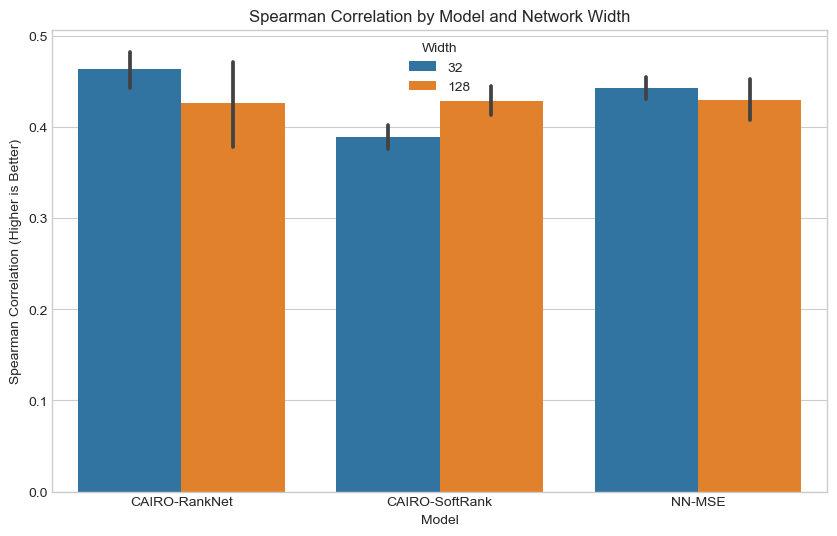

In [13]:
# ==========================================
# 0. SETUP & DEPENDENCIES
# ==========================================
try:
    import fast_soft_sort
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "fast-soft-sort"])
    import fast_soft_sort

import os
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
from lightgbm import LGBMRegressor

# Deep Learning Imports
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
import torch
import torch.nn as nn
import torch.optim as optim
from fast_soft_sort.pytorch_ops import soft_rank

# R Data Loading
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

# Configuration
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
DATA_PATH = "/Users/harrivanhems/Desktop/Mcgill/Research/PAPER/dat_clean.rda"

# ==========================================
# 1. GRID SEARCH SPACE
# ==========================================
# We will test these combinations to see where CAIRO wins
GRID_WIDTHS = [32, 128]       # Narrow vs Wide
GRID_DEPTHS = [1, 3]          # Shallow vs Deep
N_REPEATS   = 3               # Repeats per setting
EPOCHS      = 30              # Epochs per run

# ==========================================
# 2. DATA LOADING (Robust)
# ==========================================
def load_INSURANCE(path):
    print(f"Loading data from {path}...")
    try:
        robjects.r['load'](path)
        var_name = 'dat'
        raw_r_object = robjects.globalenv[var_name]
        flatten_func = robjects.r("""function(x) { return(do.call(data.frame, x)) }""")
        flat_r_object = flatten_func(raw_r_object)
        with localconverter(robjects.default_converter + pandas2ri.converter):
            df = robjects.conversion.rpy2py(flat_r_object)
        
        y = df['CLM_AMT5'].astype(np.float32)
        cols_to_drop = [c for c in ['CLM_AMT5', 'CAR_TYPE', 'JOBCLASS', 'MAX_EDUC'] if c in df.columns]
        X = df.drop(columns=cols_to_drop).fillna(df.mean()).astype(np.float32)
        return X.to_numpy(), y.to_numpy()
    except Exception as e:
        print(f"Data Load Error: {e}")
        return np.random.randn(1000, 10), np.random.randn(1000) # Fallback for debugging

# ==========================================
# 3. DYNAMIC MODEL BUILDERS
# ==========================================

# --- TensorFlow Builder (RankNet / MSE) ---
def build_tf_mlp(input_dim, width, depth, output_dim=1, activation='relu'):
    model = Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for _ in range(depth):
        model.add(layers.Dense(width, activation=activation))
    model.add(layers.Dense(output_dim))
    return model

def build_ranknet_tf(input_dim, width, depth):
    base = build_tf_mlp(input_dim, width, depth)
    in_i = layers.Input(shape=(input_dim,))
    in_j = layers.Input(shape=(input_dim,))
    score_i = base(in_i)
    score_j = base(in_j)
    diff = layers.Subtract()([score_i, score_j])
    prob = layers.Activation('sigmoid')(diff)
    return Model(inputs=[in_i, in_j], outputs=prob), base

# --- PyTorch Builder (SoftRank) ---
class DynamicTorchNet(nn.Module):
    def __init__(self, input_dim, width, depth):
        super(DynamicTorchNet, self).__init__()
        layers_list = []
        curr_dim = input_dim
        for _ in range(depth):
            layers_list.append(nn.Linear(curr_dim, width))
            layers_list.append(nn.ReLU())
            curr_dim = width
        layers_list.append(nn.Linear(curr_dim, 1))
        self.net = nn.Sequential(*layers_list)
        
    def forward(self, x):
        return self.net(x).squeeze()

# ==========================================
# 4. LOSS FUNCTIONS
# ==========================================
def soft_rank_loss(y_pred, y_true, tau=1.0):
    """
    Minimizes MSE between the SoftRank of predictions and the SoftRank of ground truth.
    This directly optimizes Spearman Correlation.
    """
    # y_pred: (Batch,)
    # y_true: (Batch,)
    # Reshape to (1, Batch) for fast_soft_sort
    pred_r = soft_rank(y_pred.unsqueeze(0), regularization_strength=tau).squeeze()
    true_r = soft_rank(y_true.unsqueeze(0), regularization_strength=tau).squeeze()
    return torch.nn.functional.mse_loss(pred_r, true_r)

# ==========================================
# 5. MAIN GRID SEARCH LOOP
# ==========================================
X_all, y_all = load_INSURANCE(DATA_PATH)
D_IN = X_all.shape[1]
print(f"Data Loaded: {X_all.shape}. Starting Grid Search...")

results = []

# Generate all combinations: (Width, Depth)
grid = list(itertools.product(GRID_WIDTHS, GRID_DEPTHS))

for (width, depth) in grid:
    print(f"\n>>> Testing Architecture: Width={width}, Depth={depth} <<<")
    
    for r in range(N_REPEATS):
        run_seed = SEED + r
        
        # 1. Splits
        X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3, random_state=run_seed)
        X_rn, X_cal, y_rn, y_cal = train_test_split(X_tr, y_tr, test_size=0.3, random_state=run_seed)
        
        # -------------------------------------------------
        # MODEL 1: CAIRO - RankNet (TF)
        # -------------------------------------------------
        rn_model, rn_scorer = build_ranknet_tf(D_IN, width, depth)
        rn_model.compile(optimizer='adam', loss='binary_crossentropy')
        
        # Pair Sampling
        rng = np.random.default_rng(run_seed)
        idx_i = rng.integers(0, len(y_rn), 20000) # 20k pairs
        idx_j = rng.integers(0, len(y_rn), 20000)
        y_pairs = (y_rn[idx_i] > y_rn[idx_j]).astype('float32')
        
        rn_model.fit([X_rn[idx_i], X_rn[idx_j]], y_pairs, epochs=EPOCHS, batch_size=1024, verbose=0)
        
        # Calibrate
        s_cal = rn_scorer.predict(X_cal, verbose=0).flatten()
        iso = IsotonicRegression(out_of_bounds="clip").fit(s_cal, y_cal)
        yhat_rn = iso.predict(rn_scorer.predict(X_te, verbose=0).flatten())

        # -------------------------------------------------
        # MODEL 2: CAIRO - SoftRank (PyTorch)
        # -------------------------------------------------
        sr_model = DynamicTorchNet(D_IN, width, depth).to(DEVICE)
        opt = optim.Adam(sr_model.parameters(), lr=0.001)
        
        X_rn_t = torch.tensor(X_rn, dtype=torch.float32).to(DEVICE)
        y_rn_t = torch.tensor(y_rn, dtype=torch.float32).to(DEVICE)
        
        sr_model.train()
        for ep in range(EPOCHS):
            # Shuffle batch for stochasticity
            perm = torch.randperm(X_rn_t.size(0))[:512] # Batch size 512 for SoftSort
            opt.zero_grad()
            preds = sr_model(X_rn_t[perm])
            loss = soft_rank_loss(preds, y_rn_t[perm], tau=1.0)
            loss.backward()
            opt.step()
            
        sr_model.eval()
        with torch.no_grad():
            s_cal_sr = sr_model(torch.tensor(X_cal, dtype=torch.float32).to(DEVICE)).cpu().numpy()
            s_te_sr  = sr_model(torch.tensor(X_te, dtype=torch.float32).to(DEVICE)).cpu().numpy()
            
        iso_sr = IsotonicRegression(out_of_bounds="clip").fit(s_cal_sr, y_cal)
        yhat_sr = iso_sr.predict(s_te_sr)

        # -------------------------------------------------
        # MODEL 3: NN-MSE (Baseline)
        # -------------------------------------------------
        mse_model = build_tf_mlp(D_IN, width, depth)
        mse_model.compile(optimizer='adam', loss='mse')
        mse_model.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=256, verbose=0)
        yhat_mse = mse_model.predict(X_te, verbose=0).flatten()

        # -------------------------------------------------
        # Save Metrics
        # -------------------------------------------------
        preds_dict = {
            "CAIRO-RankNet": yhat_rn,
            "CAIRO-SoftRank": yhat_sr,
            "NN-MSE": yhat_mse
        }
        
        for m_name, y_pred in preds_dict.items():
            sp = spearmanr(y_te, y_pred).correlation
            mse_val = np.mean((y_te - y_pred)**2)
            results.append({
                "Width": width,
                "Depth": depth,
                "Model": m_name,
                "Spearman": sp,
                "MSE": mse_val
            })

# ==========================================
# 6. ANALYSIS & PLOTTING
# ==========================================
df_res = pd.DataFrame(results)

# Aggregate results
summary = df_res.groupby(["Width", "Depth", "Model"]).agg({
    "Spearman": "mean", 
    "MSE": "mean"
}).reset_index()

# Find the "Winner" for each setting
print("\n=== GRID SEARCH SUMMARY ===")
print(summary.sort_values(by=["Width", "Depth", "Spearman"], ascending=[True, True, False]))

# Pivot for heatmap visualization
pivot_sp = summary.pivot_table(index=["Width", "Depth"], columns="Model", values="Spearman")
pivot_sp['Winner'] = pivot_sp.idxmax(axis=1)
print("\n=== WINNERS PER SETTING ===")
print(pivot_sp[['Winner']])

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=df_res, x="Model", y="Spearman", hue="Width")
plt.title("Spearman Correlation by Model and Network Width")
plt.ylabel("Spearman Correlation (Higher is Better)")
plt.show()